# 🌲 Classification avec Random Forest
## Inclusion Financière au Maroc

---
**Dataset :** `financial_inclusion_morocco.xlsx`  
**Cible :** `Financial_Inclusion` (Included / Partially Included / Excluded)  
**Algorithme :** Random Forest Classifier

---

## 📦 1. Installation & Imports

In [1]:
# Installation des librairies nécessaires
!pip install -q openpyxl plotly kaleido

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    GridSearchCV, StratifiedKFold, learning_curve
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

# Style global
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',
    'text.color': '#c9d1d9',
    'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'grid.color': '#21262d',
    'font.family': 'DejaVu Sans',
    'font.size': 11
})

PALETTE = ['#58a6ff', '#3fb950', '#f78166']
print('✅ Imports réussis!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 4.7 MB/s eta 0:00:00
✅ Imports réussis!


## 📂 2. Chargement & Exploration des Données

In [2]:
# Chargement du fichier (uploader via Colab ou chemin local)
from google.colab import files
uploaded = files.upload()  # Uploader financial_inclusion_morocco.xlsx

df = pd.read_excel('financial_inclusion_morocco.xlsx')
print(f'📊 Shape: {df.shape}')
print(f'🔢 Colonnes: {list(df.columns)}')
df.head(10)

Saving financial_inclusion_morocco.xlsx to financial_inclusion_morocco.xlsx
📊 Shape: (500, 6)
🔢 Colonnes: ['Age', 'Income_Monthly_MAD', 'Education_Level', 'Has_Bank_Account', 'Uses_Mobile_Money', 'Financial_Inclusion']


,Age,Income_Monthly_MAD,Education_Level,Has_Bank_Account,Uses_Mobile_Money,Financial_Inclusion
0,56,4843,Secondary,1,0,Partially Included
1,69,15000,Secondary,0,1,Partially Included
2,46,11162,Primary,0,0,Excluded
3,32,18464,University,0,0,Excluded
4,60,16625,University,1,1,Partially Included
5,25,9630,Primary,1,0,Partially Included
6,38,3179,University,0,1,Partially Included
7,56,5006,Primary,1,1,Partially Included
8,36,14784,Primary,0,0,Excluded
9,40,8753,Primary,1,1,Included


In [3]:
# Vue d'ensemble statistique
print('═'*60)
print('📈 STATISTIQUES DESCRIPTIVES')
print('═'*60)
display(df.describe())

print('\n🔍 Types & Valeurs manquantes:')
info_df = pd.DataFrame({
    'Type': df.dtypes,
    'Non-Null': df.count(),
    'Null': df.isnull().sum(),
    'Null%': (df.isnull().sum()/len(df)*100).round(2)
})
display(info_df)

════════════════════════════════════════════════════════════
📈 STATISTIQUES DESCRIPTIVES
════════════════════════════════════════════════════════════


,Age,Income_Monthly_MAD,Has_Bank_Account,Uses_Mobile_Money
count,500.000000,500.000000,500.000000,500.000000
mean,44.220000,10541.502000,0.504000,0.496000
std,15.036082,5187.559691,0.500485,0.500485
min,18.000000,1509.000000,0.000000,0.000000
25%,32.000000,6343.250000,0.000000,0.000000
50%,45.000000,10176.500000,1.000000,0.000000
75%,57.000000,14935.000000,1.000000,1.000000
max,69.000000,19944.000000,1.000000,1.000000



🔍 Types & Valeurs manquantes:


,Type,Non-Null,Null,Null%
Age,int64,500,0,0.0
Income_Monthly_MAD,int64,500,0,0.0
Education_Level,object,500,0,0.0
Has_Bank_Account,int64,500,0,0.0
Uses_Mobile_Money,int64,500,0,0.0
Financial_Inclusion,object,500,0,0.0


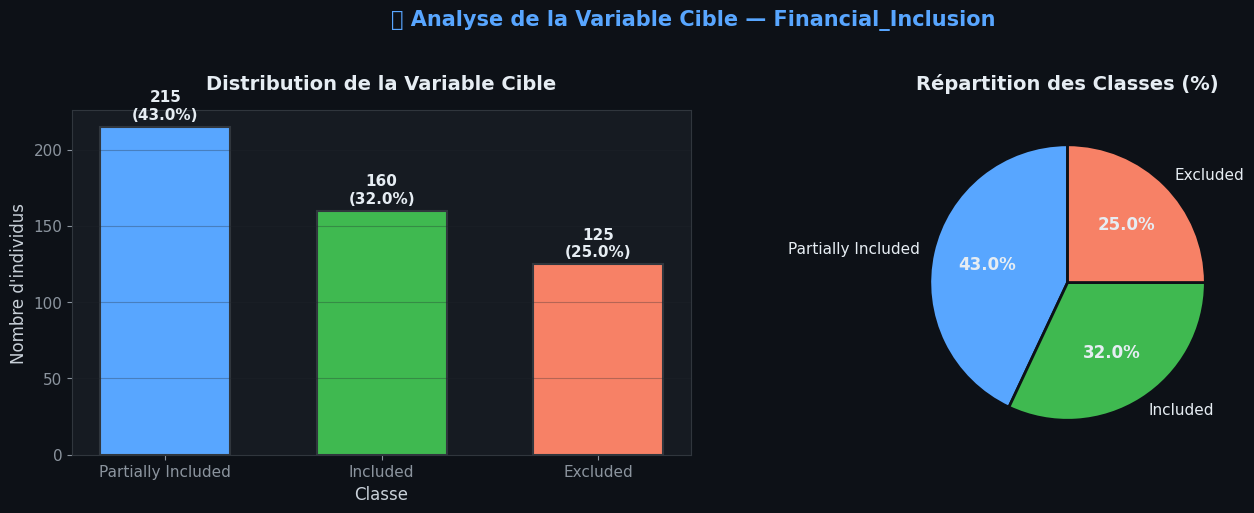

In [4]:
# Distribution de la variable cible
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d1117')

counts = df['Financial_Inclusion'].value_counts()
colors = ['#58a6ff', '#3fb950', '#f78166']

# Bar chart
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='#30363d', linewidth=1.5, width=0.6)
axes[0].set_title('Distribution de la Variable Cible', fontsize=14, fontweight='bold', color='#e6edf3', pad=15)
axes[0].set_xlabel('Classe', fontsize=12)
axes[0].set_ylabel('Nombre d\'individus', fontsize=12)
for bar, count in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 f'{count}\n({count/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=11, fontweight='bold', color='#e6edf3')
axes[0].set_facecolor('#161b22')
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=counts.index, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': '#0d1117', 'linewidth': 2},
    textprops={'color': '#e6edf3', 'fontsize': 11}
)
for at in autotexts:
    at.set_fontweight('bold')
    at.set_fontsize(12)
axes[1].set_title('Répartition des Classes (%)', fontsize=14, fontweight='bold', color='#e6edf3', pad=15)

plt.suptitle('📊 Analyse de la Variable Cible — Financial_Inclusion', fontsize=15, fontweight='bold', color='#58a6ff', y=1.02)
plt.tight_layout()
plt.show()

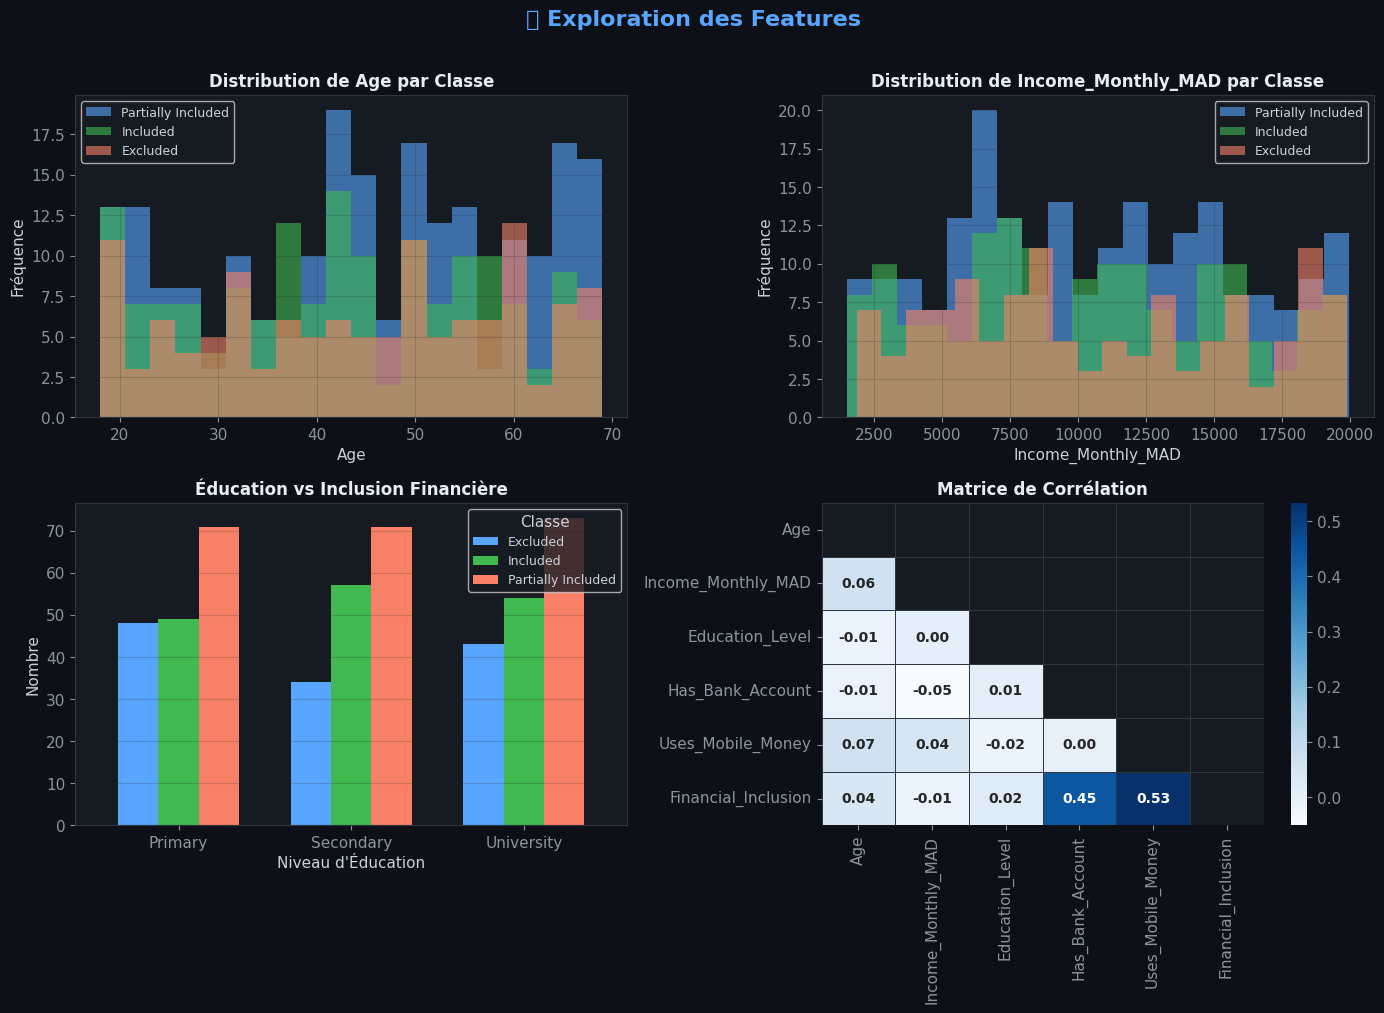

In [5]:
# Exploration des features numériques
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('#0d1117')
axes = axes.flatten()

num_cols = ['Age', 'Income_Monthly_MAD']
cat_cols = ['Education_Level', 'Has_Bank_Account', 'Uses_Mobile_Money']

# Histogrammes colorés par classe
for i, col in enumerate(num_cols):
    for j, (cls, color) in enumerate(zip(counts.index, PALETTE)):
        subset = df[df['Financial_Inclusion'] == cls][col]
        axes[i].hist(subset, bins=20, alpha=0.6, color=color, label=cls, edgecolor='none')
    axes[i].set_title(f'Distribution de {col} par Classe', fontweight='bold', color='#e6edf3', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Fréquence')
    axes[i].legend(fontsize=9)
    axes[i].set_facecolor('#161b22')
    axes[i].grid(alpha=0.2)

# Education Level distribution
edu_counts = df.groupby(['Education_Level', 'Financial_Inclusion']).size().unstack(fill_value=0)
edu_counts.plot(kind='bar', ax=axes[2], color=PALETTE, edgecolor='none', width=0.7)
axes[2].set_title('Éducation vs Inclusion Financière', fontweight='bold', color='#e6edf3', fontsize=12)
axes[2].set_xlabel('Niveau d\'Éducation')
axes[2].set_ylabel('Nombre')
axes[2].legend(title='Classe', fontsize=9)
axes[2].set_facecolor('#161b22')
axes[2].grid(axis='y', alpha=0.2)
axes[2].tick_params(axis='x', rotation=0)

# Corrélation
df_encoded = df.copy()
le = LabelEncoder()
df_encoded['Education_Level'] = le.fit_transform(df['Education_Level'])
df_encoded['Financial_Inclusion'] = le.fit_transform(df['Financial_Inclusion'])
corr = df_encoded.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', ax=axes[3],
            cmap='Blues', linewidths=0.5, linecolor='#30363d',
            annot_kws={'size': 10, 'weight': 'bold'})
axes[3].set_title('Matrice de Corrélation', fontweight='bold', color='#e6edf3', fontsize=12)
axes[3].set_facecolor('#161b22')

plt.suptitle('🔍 Exploration des Features', fontsize=16, fontweight='bold', color='#58a6ff', y=1.01)
plt.tight_layout()
plt.show()

## ⚙️ 3. Prétraitement des Données

In [6]:
# Encodage des variables catégorielles
df_proc = df.copy()

le_edu = LabelEncoder()
le_target = LabelEncoder()

df_proc['Education_Level'] = le_edu.fit_transform(df['Education_Level'])
df_proc['Financial_Inclusion'] = le_target.fit_transform(df['Financial_Inclusion'])

print('🏷️ Mapping Education_Level:', dict(zip(le_edu.classes_, le_edu.transform(le_edu.classes_))))
print('🏷️ Mapping Financial_Inclusion:', dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))

# Séparation features / cible
X = df_proc.drop('Financial_Inclusion', axis=1)
y = df_proc['Financial_Inclusion']

print(f'\n✅ X shape: {X.shape}')
print(f'✅ y shape: {y.shape}')
print(f'\n📋 Features utilisées: {list(X.columns)}')
print(f'📋 Classes cible: {le_target.classes_}')

# Train / Test split stratifié
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\n🔀 Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')

🏷️ Mapping Education_Level: {'Primary': np.int64(0), 'Secondary': np.int64(1), 'University': np.int64(2)}
🏷️ Mapping Financial_Inclusion: {'Excluded': np.int64(0), 'Included': np.int64(1), 'Partially Included': np.int64(2)}

✅ X shape: (500, 5)
✅ y shape: (500,)

📋 Features utilisées: ['Age', 'Income_Monthly_MAD', 'Education_Level', 'Has_Bank_Account', 'Uses_Mobile_Money']
📋 Classes cible: ['Excluded' 'Included' 'Partially Included']

🔀 Train: 400 samples | Test: 100 samples


## 🌲 4. Entraînement du Random Forest

In [7]:
# Modèle de base
rf_base = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_base.fit(X_train, y_train)

y_pred = rf_base.predict(X_test)
acc_base = accuracy_score(y_test, y_pred)
print(f'🎯 Accuracy (modèle de base): {acc_base:.4f} ({acc_base*100:.2f}%)')

🎯 Accuracy (modèle de base): 0.6400 (64.00%)


In [8]:
# Optimisation par GridSearchCV
print('⚙️ GridSearchCV en cours (patience...)\n')

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

rf_grid = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    rf_grid, param_grid, cv=cv,
    scoring='accuracy', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print(f'\n🏆 Meilleurs paramètres:')
for k, v in grid_search.best_params_.items():
    print(f'   {k}: {v}')
print(f'\n✅ Meilleur score CV: {grid_search.best_score_:.4f} ({grid_search.best_score_*100:.2f}%)')

best_rf = grid_search.best_estimator_

⚙️ GridSearchCV en cours (patience...)

Fitting 5 folds for each of 96 candidates, totalling 480 fits

🏆 Meilleurs paramètres:
   max_depth: 15
   max_features: sqrt
   min_samples_leaf: 1
   min_samples_split: 2
   n_estimators: 100

✅ Meilleur score CV: 0.6675 (66.75%)


## 📊 5. Évaluation du Modèle

In [9]:
# Prédictions finales
y_pred_best = best_rf.predict(X_test)
y_proba_best = best_rf.predict_proba(X_test)

acc_best = accuracy_score(y_test, y_pred_best)
print('='*60)
print('📋 RAPPORT DE CLASSIFICATION DÉTAILLÉ')
print('='*60)
print(classification_report(
    y_test, y_pred_best,
    target_names=le_target.classes_
))
print(f'🎯 Accuracy finale : {acc_best:.4f} ({acc_best*100:.2f}%)')

# Cross-validation sur le meilleur modèle
cv_scores = cross_val_score(best_rf, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
print(f'\n🔄 Cross-Validation (5 folds):')
print(f'   Scores: {[f"{s:.4f}" for s in cv_scores]}')
print(f'   Moyenne: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

📋 RAPPORT DE CLASSIFICATION DÉTAILLÉ
                    precision    recall  f1-score   support

          Excluded       1.00      1.00      1.00        25
          Included       0.44      0.38      0.41        32
Partially Included       0.58      0.65      0.62        43

          accuracy                           0.65       100
         macro avg       0.68      0.68      0.67       100
      weighted avg       0.64      0.65      0.64       100

🎯 Accuracy finale : 0.6500 (65.00%)

🔄 Cross-Validation (5 folds):
   Scores: ['0.6900', '0.6800', '0.6400', '0.7200', '0.5700']
   Moyenne: 0.6600 ± 0.0518


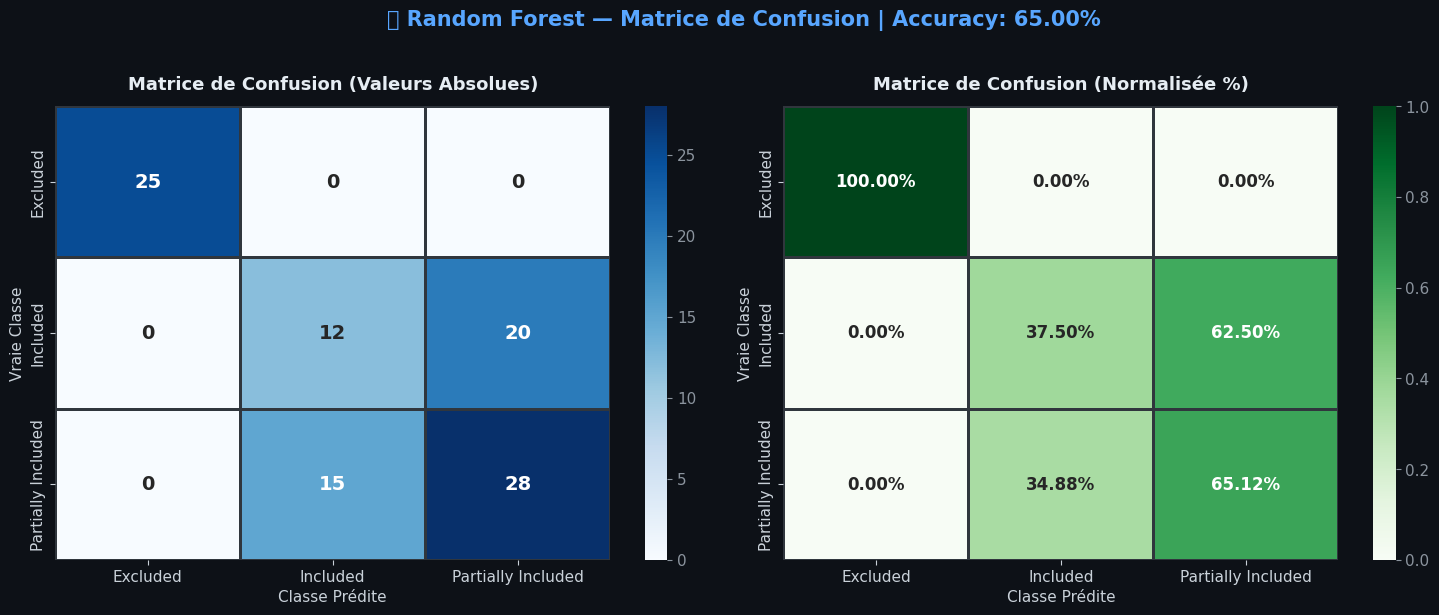

In [10]:
# Matrice de confusion enrichie
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('#0d1117')

cm = confusion_matrix(y_test, y_pred_best)
classes = le_target.classes_

# Matrice absolue
sns.heatmap(cm, annot=True, fmt='d', ax=axes[0],
            cmap='Blues', linewidths=1, linecolor='#30363d',
            xticklabels=classes, yticklabels=classes,
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title('Matrice de Confusion (Valeurs Absolues)',
                   fontweight='bold', color='#e6edf3', fontsize=13, pad=12)
axes[0].set_ylabel('Vraie Classe', fontsize=11)
axes[0].set_xlabel('Classe Prédite', fontsize=11)
axes[0].set_facecolor('#161b22')
axes[0].tick_params(colors='#c9d1d9')

# Matrice normalisée
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', ax=axes[1],
            cmap='Greens', linewidths=1, linecolor='#30363d',
            xticklabels=classes, yticklabels=classes,
            annot_kws={'size': 12, 'weight': 'bold'})
axes[1].set_title('Matrice de Confusion (Normalisée %)',
                   fontweight='bold', color='#e6edf3', fontsize=13, pad=12)
axes[1].set_ylabel('Vraie Classe', fontsize=11)
axes[1].set_xlabel('Classe Prédite', fontsize=11)
axes[1].set_facecolor('#161b22')
axes[1].tick_params(colors='#c9d1d9')

plt.suptitle(f'🌲 Random Forest — Matrice de Confusion | Accuracy: {acc_best*100:.2f}%',
             fontsize=15, fontweight='bold', color='#58a6ff', y=1.02)
plt.tight_layout()
plt.show()

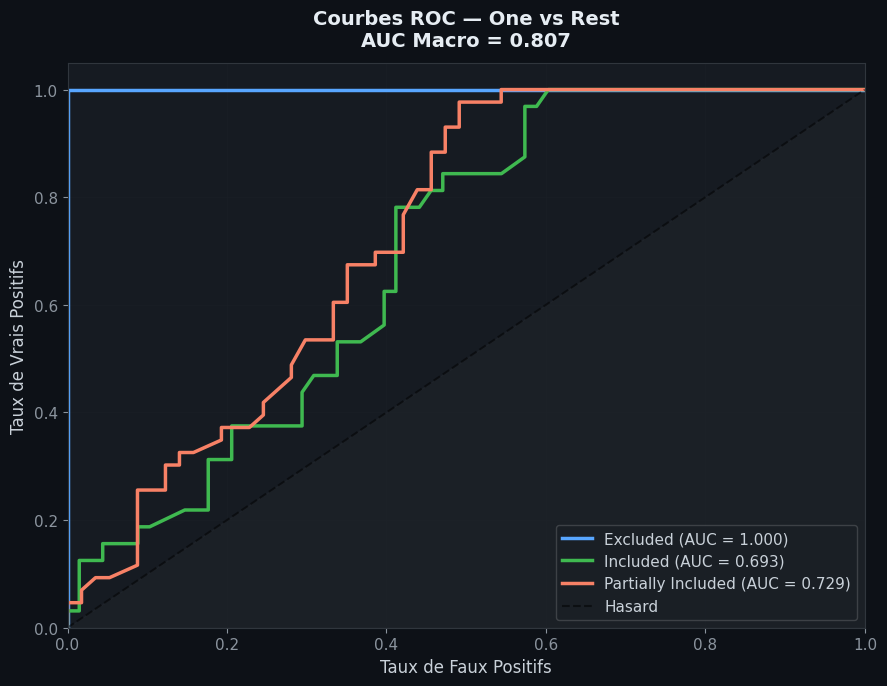

In [11]:
# Courbes ROC — One vs Rest
from sklearn.preprocessing import label_binarize

n_classes = len(le_target.classes_)
y_test_bin = label_binarize(y_test, classes=range(n_classes))

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

auc_scores = []
for i, (cls_name, color) in enumerate(zip(le_target.classes_, PALETTE)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_best[:, i])
    auc_val = roc_auc_score(y_test_bin[:, i], y_proba_best[:, i])
    auc_scores.append(auc_val)
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f'{cls_name} (AUC = {auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.5, label='Hasard')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')

ax.set_xlabel('Taux de Faux Positifs', fontsize=12)
ax.set_ylabel('Taux de Vrais Positifs', fontsize=12)
ax.set_title(f'Courbes ROC — One vs Rest\nAUC Macro = {np.mean(auc_scores):.3f}',
             fontsize=14, fontweight='bold', color='#e6edf3', pad=12)
ax.legend(loc='lower right', fontsize=11, framealpha=0.2)
ax.grid(alpha=0.2)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

## 🔍 6. Importance des Features

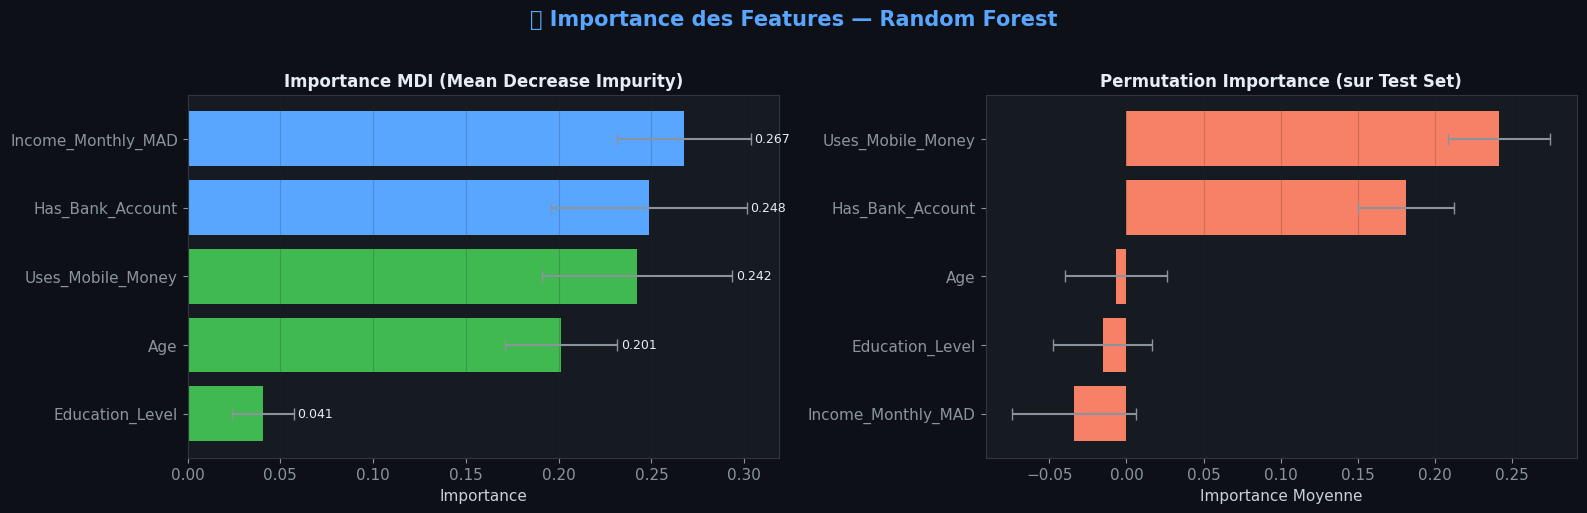


📊 Tableau récapitulatif:


,Feature,MDI_Importance,MDI_Std,Perm_Importance,Perm_Std
0,Income_Monthly_MAD,0.2675,0.0361,-0.0340,0.0399
1,Has_Bank_Account,0.2485,0.0529,0.1813,0.0310
2,Uses_Mobile_Money,0.2421,0.0514,0.2417,0.0330
3,Age,0.2013,0.0301,-0.0070,0.0330
4,Education_Level,0.0406,0.0167,-0.0153,0.0321


In [12]:
# Feature Importance — 3 méthodes
feature_names = X.columns.tolist()

# 1. Importance MDI (Mean Decrease Impurity)
importances_mdi = best_rf.feature_importances_
std_mdi = np.std([tree.feature_importances_ for tree in best_rf.estimators_], axis=0)

# 2. Permutation Importance
perm_imp = permutation_importance(best_rf, X_test, y_test, n_repeats=30, random_state=42, n_jobs=-1)

# DataFrame comparatif
fi_df = pd.DataFrame({
    'Feature': feature_names,
    'MDI_Importance': importances_mdi,
    'MDI_Std': std_mdi,
    'Perm_Importance': perm_imp.importances_mean,
    'Perm_Std': perm_imp.importances_std
}).sort_values('MDI_Importance', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0d1117')

# MDI
fi_sorted = fi_df.sort_values('MDI_Importance')
colors_bar = ['#58a6ff' if v > fi_sorted['MDI_Importance'].median() else '#3fb950'
               for v in fi_sorted['MDI_Importance']]
axes[0].barh(fi_sorted['Feature'], fi_sorted['MDI_Importance'],
             xerr=fi_sorted['MDI_Std'], color=colors_bar,
             edgecolor='none', capsize=4, error_kw={'ecolor': '#8b949e', 'linewidth': 1.5})
axes[0].set_title('Importance MDI (Mean Decrease Impurity)',
                   fontweight='bold', color='#e6edf3', fontsize=12)
axes[0].set_xlabel('Importance')
axes[0].set_facecolor('#161b22')
axes[0].grid(axis='x', alpha=0.2)
for i, (val, std) in enumerate(zip(fi_sorted['MDI_Importance'], fi_sorted['MDI_Std'])):
    axes[0].text(val + std + 0.002, i, f'{val:.3f}', va='center', fontsize=9, color='#e6edf3')

# Permutation
fi_perm = fi_df.sort_values('Perm_Importance')
axes[1].barh(fi_perm['Feature'], fi_perm['Perm_Importance'],
             xerr=fi_perm['Perm_Std'], color='#f78166',
             edgecolor='none', capsize=4, error_kw={'ecolor': '#8b949e', 'linewidth': 1.5})
axes[1].set_title('Permutation Importance (sur Test Set)',
                   fontweight='bold', color='#e6edf3', fontsize=12)
axes[1].set_xlabel('Importance Moyenne')
axes[1].set_facecolor('#161b22')
axes[1].grid(axis='x', alpha=0.2)

plt.suptitle('🔍 Importance des Features — Random Forest',
             fontsize=15, fontweight='bold', color='#58a6ff', y=1.02)
plt.tight_layout()
plt.show()

print('\n📊 Tableau récapitulatif:')
display(fi_df.round(4))

## 📈 7. Courbe d'Apprentissage & Évolution OOB

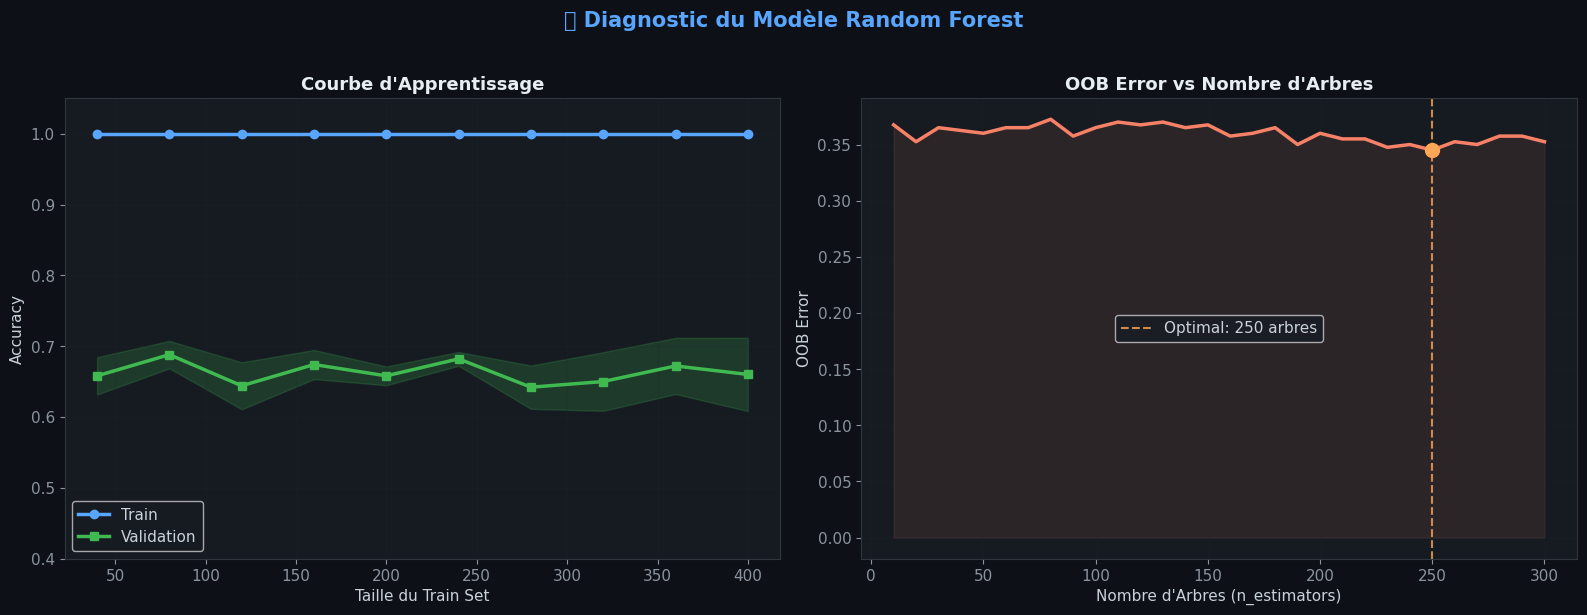

In [13]:
# Learning Curve
train_sizes, train_scores, val_scores = learning_curve(
    best_rf, X, y, cv=cv, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)
val_std    = np.std(val_scores, axis=1)

# OOB Error vs n_estimators
n_estimators_range = range(10, 301, 10)
oob_errors = []
for n in n_estimators_range:
    rf_oob = RandomForestClassifier(
        n_estimators=n, oob_score=True,
        class_weight='balanced', random_state=42, n_jobs=-1,
        **{k: v for k, v in grid_search.best_params_.items() if k != 'n_estimators'}
    )
    rf_oob.fit(X_train, y_train)
    oob_errors.append(1 - rf_oob.oob_score_)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0d1117')

# Learning Curve
axes[0].plot(train_sizes, train_mean, 'o-', color='#58a6ff', linewidth=2.5, label='Train')
axes[0].fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='#58a6ff')
axes[0].plot(train_sizes, val_mean, 's-', color='#3fb950', linewidth=2.5, label='Validation')
axes[0].fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='#3fb950')
axes[0].set_title('Courbe d\'Apprentissage', fontweight='bold', color='#e6edf3', fontsize=13)
axes[0].set_xlabel('Taille du Train Set')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=11)
axes[0].set_facecolor('#161b22')
axes[0].grid(alpha=0.2)
axes[0].set_ylim([0.4, 1.05])

# OOB Error
axes[1].plot(list(n_estimators_range), oob_errors, color='#f78166', linewidth=2.5)
axes[1].fill_between(list(n_estimators_range), oob_errors, alpha=0.1, color='#f78166')
best_n = list(n_estimators_range)[np.argmin(oob_errors)]
axes[1].axvline(x=best_n, color='#ffa657', linestyle='--', linewidth=1.5, alpha=0.8,
                label=f'Optimal: {best_n} arbres')
axes[1].scatter([best_n], [min(oob_errors)], color='#ffa657', s=100, zorder=5)
axes[1].set_title('OOB Error vs Nombre d\'Arbres', fontweight='bold', color='#e6edf3', fontsize=13)
axes[1].set_xlabel('Nombre d\'Arbres (n_estimators)')
axes[1].set_ylabel('OOB Error')
axes[1].legend(fontsize=11)
axes[1].set_facecolor('#161b22')
axes[1].grid(alpha=0.2)

plt.suptitle('📈 Diagnostic du Modèle Random Forest',
             fontsize=15, fontweight='bold', color='#58a6ff', y=1.02)
plt.tight_layout()
plt.show()

## 🎯 8. Résumé & Tableau de Bord Final

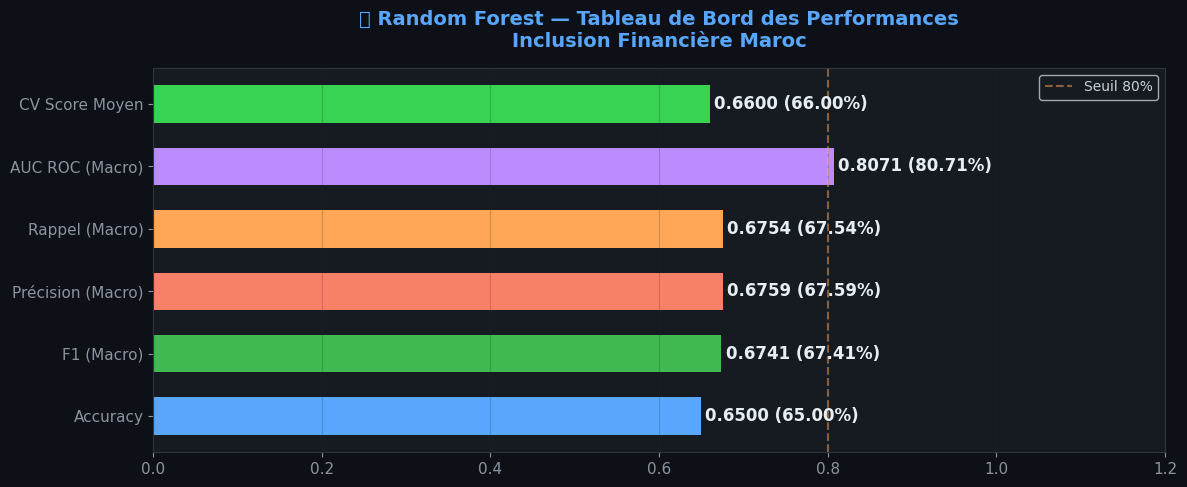


════════════════════════════════════════════════════════════
🏆 RÉSUMÉ FINAL — RANDOM FOREST
════════════════════════════════════════════════════════════
  Accuracy                 : 0.6500 (65.00%)
  F1 (Macro)               : 0.6741 (67.41%)
  Précision (Macro)        : 0.6759 (67.59%)
  Rappel (Macro)           : 0.6754 (67.54%)
  AUC ROC (Macro)          : 0.8071 (80.71%)
  CV Score Moyen           : 0.6600 (66.00%)
════════════════════════════════════════════════════════════
  Meilleurs hyperparamètres : {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
════════════════════════════════════════════════════════════


In [14]:
# Tableau de bord récapitulatif
from sklearn.metrics import f1_score, precision_score, recall_score

metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_best),
    'F1 (Macro)': f1_score(y_test, y_pred_best, average='macro'),
    'Précision (Macro)': precision_score(y_test, y_pred_best, average='macro'),
    'Rappel (Macro)': recall_score(y_test, y_pred_best, average='macro'),
    'AUC ROC (Macro)': roc_auc_score(y_test_bin, y_proba_best, multi_class='ovr', average='macro'),
    'CV Score Moyen': cv_scores.mean()
}

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

metric_names = list(metrics.keys())
metric_vals  = list(metrics.values())
bar_colors = ['#58a6ff', '#3fb950', '#f78166', '#ffa657', '#bc8cff', '#39d353']

bars = ax.barh(metric_names, metric_vals, color=bar_colors, edgecolor='none', height=0.6)
for bar, val in zip(bars, metric_vals):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f} ({val*100:.2f}%)', va='center', fontsize=12, fontweight='bold', color='#e6edf3')

ax.set_xlim([0, 1.2])
ax.set_title('🌲 Random Forest — Tableau de Bord des Performances\nInclusion Financière Maroc',
             fontsize=14, fontweight='bold', color='#58a6ff', pad=15)
ax.axvline(x=0.8, color='#ffa657', linestyle='--', linewidth=1.5, alpha=0.5, label='Seuil 80%')
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.2)

plt.tight_layout()
plt.show()

print('\n' + '═'*60)
print('🏆 RÉSUMÉ FINAL — RANDOM FOREST')
print('═'*60)
for name, val in metrics.items():
    print(f'  {name:<25}: {val:.4f} ({val*100:.2f}%)')
print('═'*60)
print(f'  Meilleurs hyperparamètres : {grid_search.best_params_}')
print('═'*60)

# 🌳 Classification avec Arbre de Décision
## Inclusion Financière au Maroc

---
**Dataset :** `financial_inclusion_morocco.xlsx`  
**Cible :** `Financial_Inclusion` (Included / Partially Included / Excluded)  
**Algorithme :** Decision Tree Classifier

---

## 📦 1. Installation & Imports

In [15]:
!pip install -q openpyxl dtreeviz graphviz plotly kaleido

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.tree import DecisionTreeClassifier, export_graphviz, plot_tree
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    GridSearchCV, StratifiedKFold, learning_curve,
    validation_curve
)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score
)
from sklearn.preprocessing import label_binarize

# Style global
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',
    'text.color': '#c9d1d9',
    'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'grid.color': '#21262d',
    'font.size': 11
})

PALETTE = ['#58a6ff', '#3fb950', '#f78166']
print('✅ Imports réussis!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 4.0 MB/s eta 0:00:00
✅ Imports réussis!


## 📂 2. Chargement & Prétraitement

In [16]:
from google.colab import files
uploaded = files.upload()  # Uploader financial_inclusion_morocco.xlsx

df = pd.read_excel('financial_inclusion_morocco.xlsx')
print(f'📊 Shape: {df.shape}')
display(df.head(8))
print('\n📈 Distribution cible:')
display(df['Financial_Inclusion'].value_counts())

Saving financial_inclusion_morocco.xlsx to financial_inclusion_morocco (1).xlsx
📊 Shape: (500, 6)


,Age,Income_Monthly_MAD,Education_Level,Has_Bank_Account,Uses_Mobile_Money,Financial_Inclusion
0,56,4843,Secondary,1,0,Partially Included
1,69,15000,Secondary,0,1,Partially Included
2,46,11162,Primary,0,0,Excluded
3,32,18464,University,0,0,Excluded
4,60,16625,University,1,1,Partially Included
5,25,9630,Primary,1,0,Partially Included
6,38,3179,University,0,1,Partially Included
7,56,5006,Primary,1,1,Partially Included



📈 Distribution cible:


,count
Financial_Inclusion,
Partially Included,215
Included,160
Excluded,125


In [17]:
# Prétraitement
df_proc = df.copy()
le_edu = LabelEncoder()
le_target = LabelEncoder()

df_proc['Education_Level'] = le_edu.fit_transform(df['Education_Level'])
df_proc['Financial_Inclusion'] = le_target.fit_transform(df['Financial_Inclusion'])

X = df_proc.drop('Financial_Inclusion', axis=1)
y = df_proc['Financial_Inclusion']

print('🏷️ Education_Level:', dict(zip(le_edu.classes_, le_edu.transform(le_edu.classes_))))
print('🏷️ Financial_Inclusion:', dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f'\n✅ Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

🏷️ Education_Level: {'Primary': np.int64(0), 'Secondary': np.int64(1), 'University': np.int64(2)}
🏷️ Financial_Inclusion: {'Excluded': np.int64(0), 'Included': np.int64(1), 'Partially Included': np.int64(2)}

✅ Train: 400 | Test: 100


## 🌳 3. Entraînement & Optimisation

In [18]:
# Modèle de base — pas d'élagage
dt_full = DecisionTreeClassifier(
    criterion='gini',
    max_depth=None,
    class_weight='balanced',
    random_state=42
)
dt_full.fit(X_train, y_train)
print(f'🌲 Arbre COMPLET: profondeur={dt_full.get_depth()}, feuilles={dt_full.get_n_leaves()}')
print(f'   Accuracy train: {dt_full.score(X_train, y_train):.4f}')
print(f'   Accuracy test : {dt_full.score(X_test, y_test):.4f}')
print(f'   → Surapprentissage? {"OUI ⚠️" if dt_full.score(X_train, y_train) - dt_full.score(X_test, y_test) > 0.1 else "NON ✅"}')

🌲 Arbre COMPLET: profondeur=16, feuilles=131
   Accuracy train: 1.0000
   Accuracy test : 0.6100
   → Surapprentissage? OUI ⚠️


In [19]:
# GridSearchCV pour trouver les meilleurs hyperparamètres
param_grid = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [2, 3, 4, 5, 6, 7, 8, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2'],
    'ccp_alpha': [0.0, 0.001, 0.005, 0.01]
}

dt_grid = DecisionTreeClassifier(class_weight='balanced', random_state=42)
grid_search = GridSearchCV(
    dt_grid, param_grid, cv=cv,
    scoring='accuracy', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print(f'\n🏆 Meilleurs paramètres:')
for k, v in grid_search.best_params_.items():
    print(f'   {k}: {v}')
print(f'\n✅ Meilleur score CV: {grid_search.best_score_:.4f}')

best_dt = grid_search.best_estimator_
print(f'\n🌲 Arbre OPTIMAL: profondeur={best_dt.get_depth()}, feuilles={best_dt.get_n_leaves()}')

Fitting 5 folds for each of 5184 candidates, totalling 25920 fits

🏆 Meilleurs paramètres:
   ccp_alpha: 0.0
   criterion: entropy
   max_depth: 10
   max_features: None
   min_samples_leaf: 2
   min_samples_split: 2

✅ Meilleur score CV: 0.6750

🌲 Arbre OPTIMAL: profondeur=10, feuilles=83


## 🎨 4. Visualisation de l'Arbre de Décision

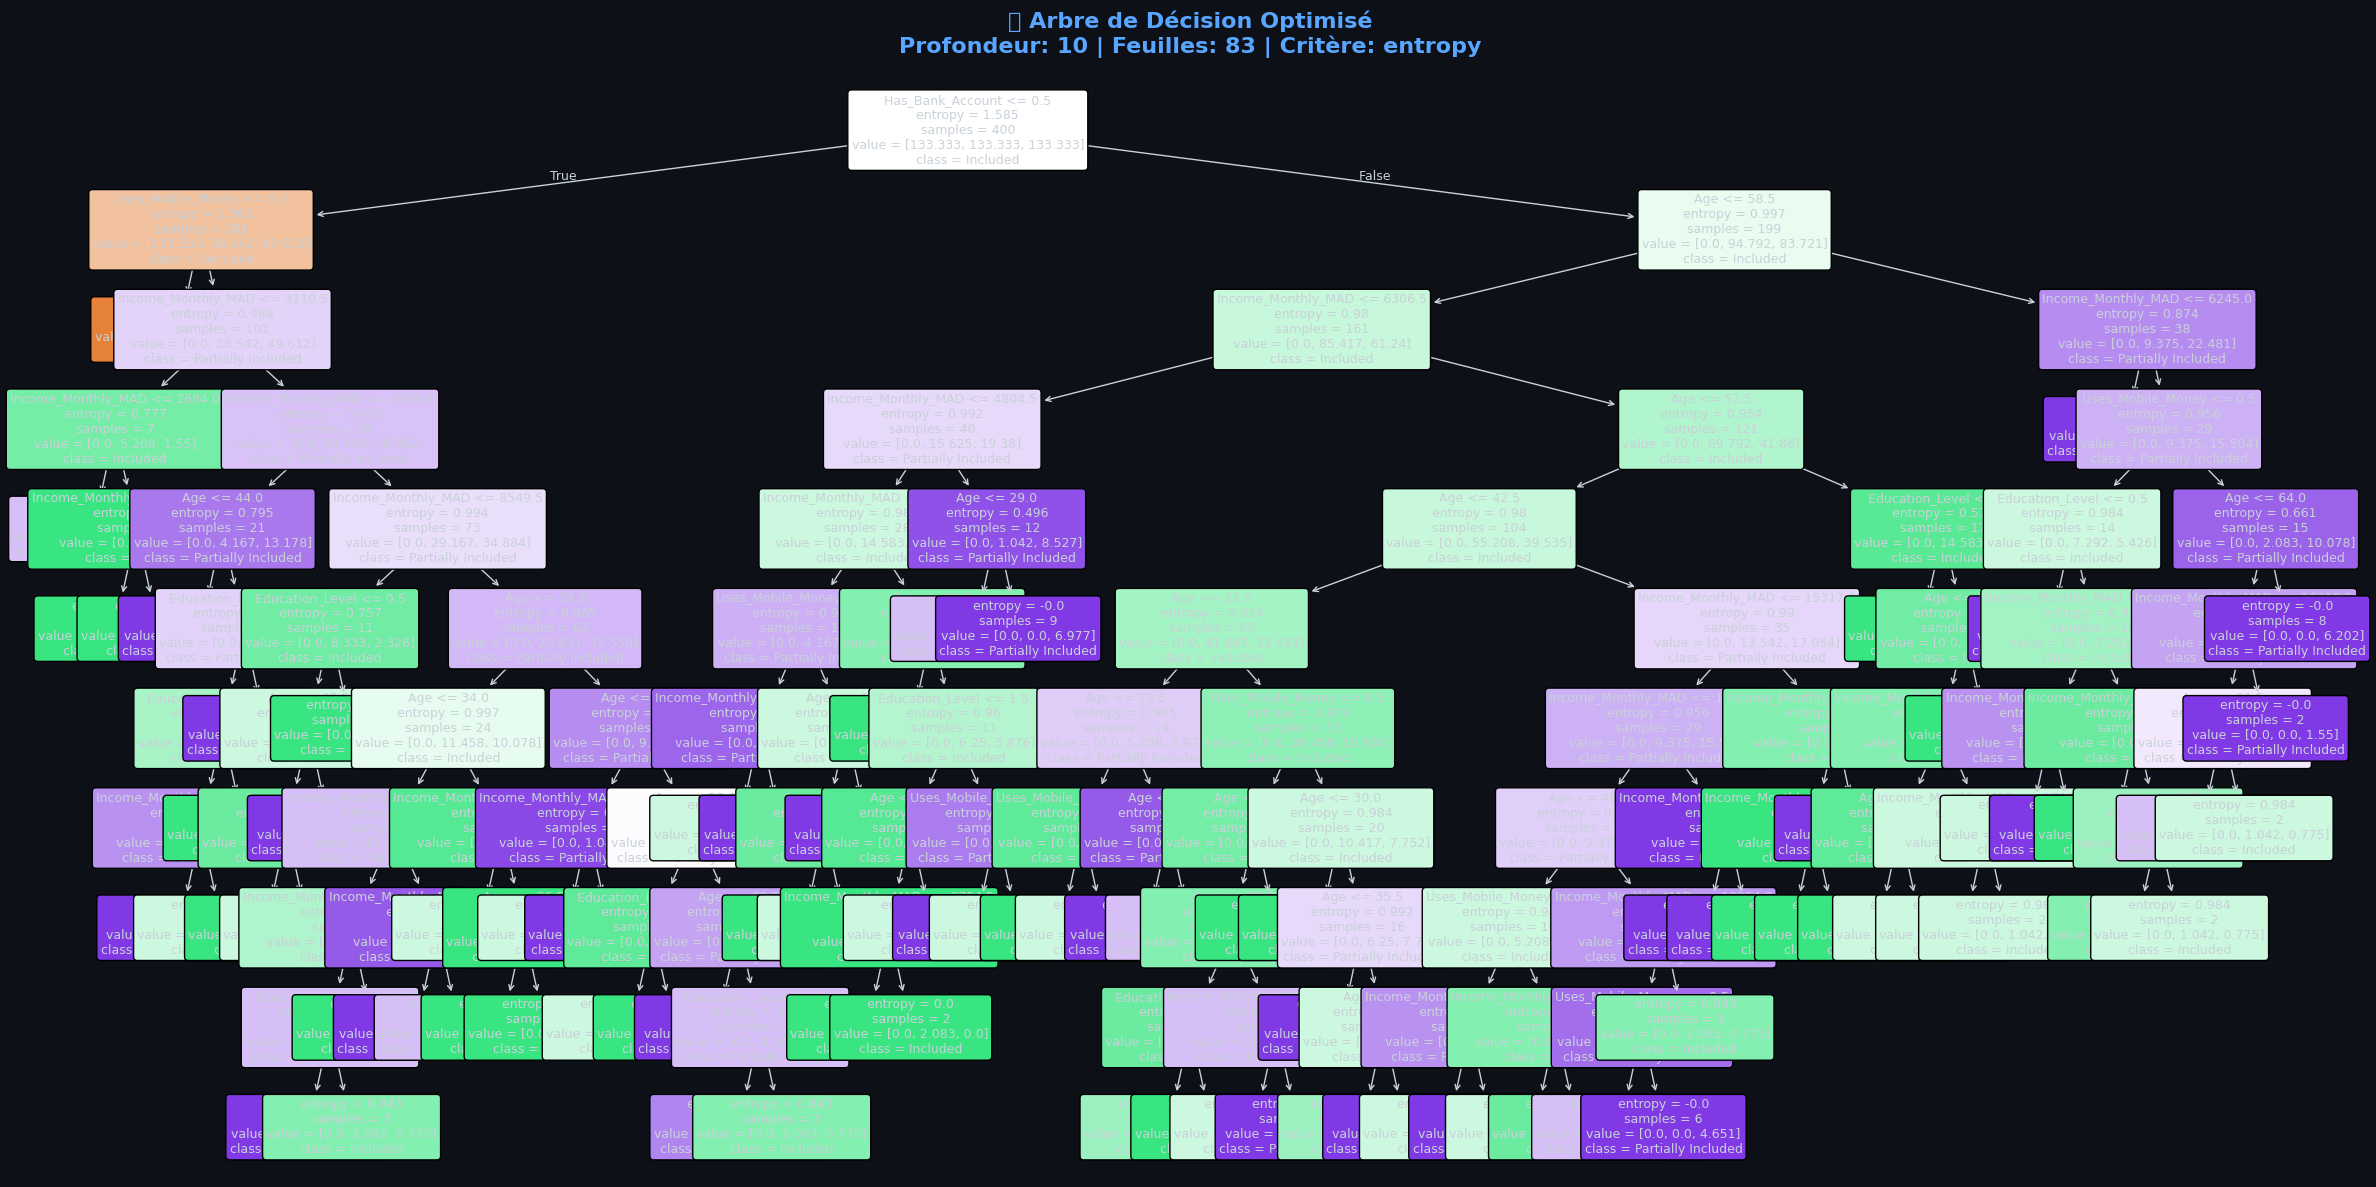

📁 Arbre sauvegardé : decision_tree_viz.png


In [20]:
# Visualisation de l'arbre optimisé
fig, ax = plt.subplots(figsize=(24, 12))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

plot_tree(
    best_dt,
    feature_names=X.columns.tolist(),
    class_names=le_target.classes_,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
    impurity=True,
    proportion=False,
    precision=3
)

ax.set_title(
    f'🌳 Arbre de Décision Optimisé\n'
    f'Profondeur: {best_dt.get_depth()} | Feuilles: {best_dt.get_n_leaves()} | '
    f'Critère: {best_dt.criterion}',
    fontsize=16, fontweight='bold', color='#58a6ff', pad=20
)

plt.tight_layout()
plt.savefig('decision_tree_viz.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117', edgecolor='none')
plt.show()
print('📁 Arbre sauvegardé : decision_tree_viz.png')

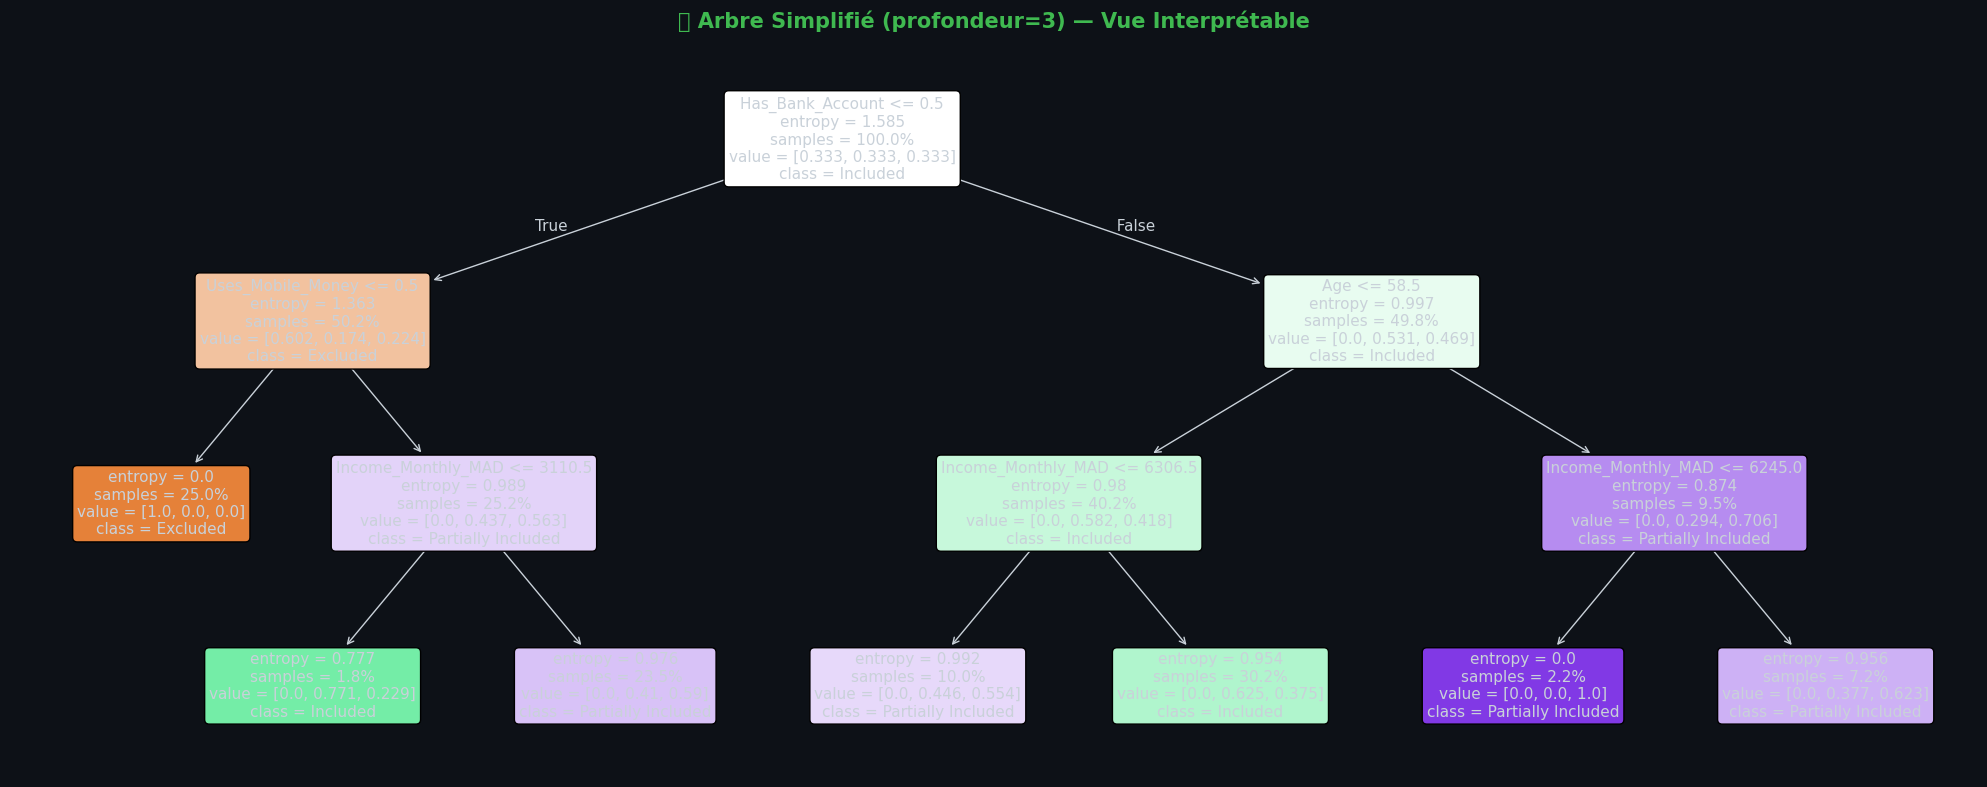

   Accuracy arbre simplifié: 0.6400


In [21]:
# Arbre simplifié (max_depth=3) pour lecture facile
dt_simple = DecisionTreeClassifier(
    max_depth=3, criterion=best_dt.criterion,
    class_weight='balanced', random_state=42
)
dt_simple.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(20, 8))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

plot_tree(
    dt_simple,
    feature_names=X.columns.tolist(),
    class_names=le_target.classes_,
    filled=True, rounded=True,
    fontsize=11, ax=ax,
    impurity=True, proportion=True, precision=3
)
ax.set_title(
    '🌱 Arbre Simplifié (profondeur=3) — Vue Interprétable',
    fontsize=15, fontweight='bold', color='#3fb950', pad=15
)
plt.tight_layout()
plt.show()

print(f'   Accuracy arbre simplifié: {dt_simple.score(X_test, y_test):.4f}')

## 📊 5. Évaluation & Analyse des Performances

In [22]:
# Prédictions
y_pred = best_dt.predict(X_test)
y_proba = best_dt.predict_proba(X_test)
acc = accuracy_score(y_test, y_pred)

print('='*60)
print('📋 RAPPORT DE CLASSIFICATION')
print('='*60)
print(classification_report(y_test, y_pred, target_names=le_target.classes_))
print(f'🎯 Accuracy: {acc:.4f} ({acc*100:.2f}%)')

cv_scores = cross_val_score(best_dt, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
print(f'\n🔄 CV (5 folds): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

📋 RAPPORT DE CLASSIFICATION
                    precision    recall  f1-score   support

          Excluded       1.00      1.00      1.00        25
          Included       0.46      0.53      0.49        32
Partially Included       0.61      0.53      0.57        43

          accuracy                           0.65       100
         macro avg       0.69      0.69      0.69       100
      weighted avg       0.66      0.65      0.65       100

🎯 Accuracy: 0.6500 (65.00%)

🔄 CV (5 folds): 0.6380 ± 0.0271


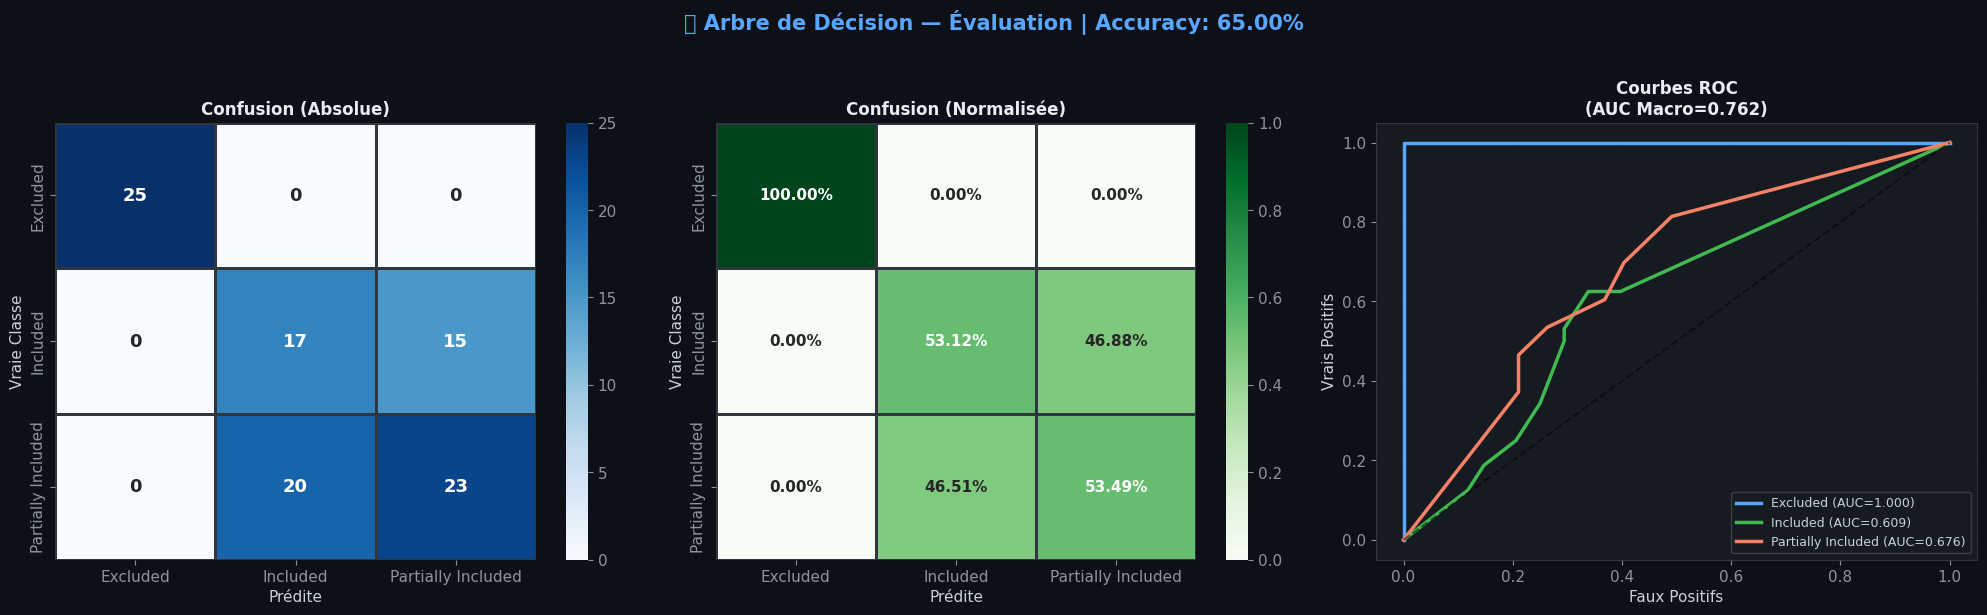

In [23]:
# Matrices de confusion + ROC
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_facecolor('#0d1117')

cm = confusion_matrix(y_test, y_pred)
classes = le_target.classes_

# Confusion absolue
sns.heatmap(cm, annot=True, fmt='d', ax=axes[0], cmap='Blues',
            linewidths=1, linecolor='#30363d',
            xticklabels=classes, yticklabels=classes,
            annot_kws={'size': 13, 'weight': 'bold'})
axes[0].set_title('Confusion (Absolue)', fontweight='bold', color='#e6edf3', fontsize=12)
axes[0].set_ylabel('Vraie Classe')
axes[0].set_xlabel('Prédite')
axes[0].set_facecolor('#161b22')

# Confusion normalisée
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', ax=axes[1], cmap='Greens',
            linewidths=1, linecolor='#30363d',
            xticklabels=classes, yticklabels=classes,
            annot_kws={'size': 11, 'weight': 'bold'})
axes[1].set_title('Confusion (Normalisée)', fontweight='bold', color='#e6edf3', fontsize=12)
axes[1].set_ylabel('Vraie Classe')
axes[1].set_xlabel('Prédite')
axes[1].set_facecolor('#161b22')

# ROC Curves
n_classes = len(classes)
y_test_bin = label_binarize(y_test, classes=range(n_classes))
axes[2].set_facecolor('#161b22')
auc_scores = []
for i, (cls_name, color) in enumerate(zip(classes, PALETTE)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    auc_val = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    auc_scores.append(auc_val)
    axes[2].plot(fpr, tpr, color=color, linewidth=2.5, label=f'{cls_name} (AUC={auc_val:.3f})')
axes[2].plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.5)
axes[2].set_title('Courbes ROC — One vs Rest', fontweight='bold', color='#e6edf3', fontsize=12)
axes[2].set_xlabel('Faux Positifs')
axes[2].set_ylabel('Vrais Positifs')
axes[2].legend(fontsize=9, framealpha=0.2)
axes[2].grid(alpha=0.2)
axes[2].set_title(f'Courbes ROC\n(AUC Macro={np.mean(auc_scores):.3f})',
                   fontweight='bold', color='#e6edf3', fontsize=12)

plt.suptitle(f'🌳 Arbre de Décision — Évaluation | Accuracy: {acc*100:.2f}%',
             fontsize=15, fontweight='bold', color='#58a6ff', y=1.02)
plt.tight_layout()
plt.show()

## 🔎 6. Analyse du Surapprentissage & Élagage

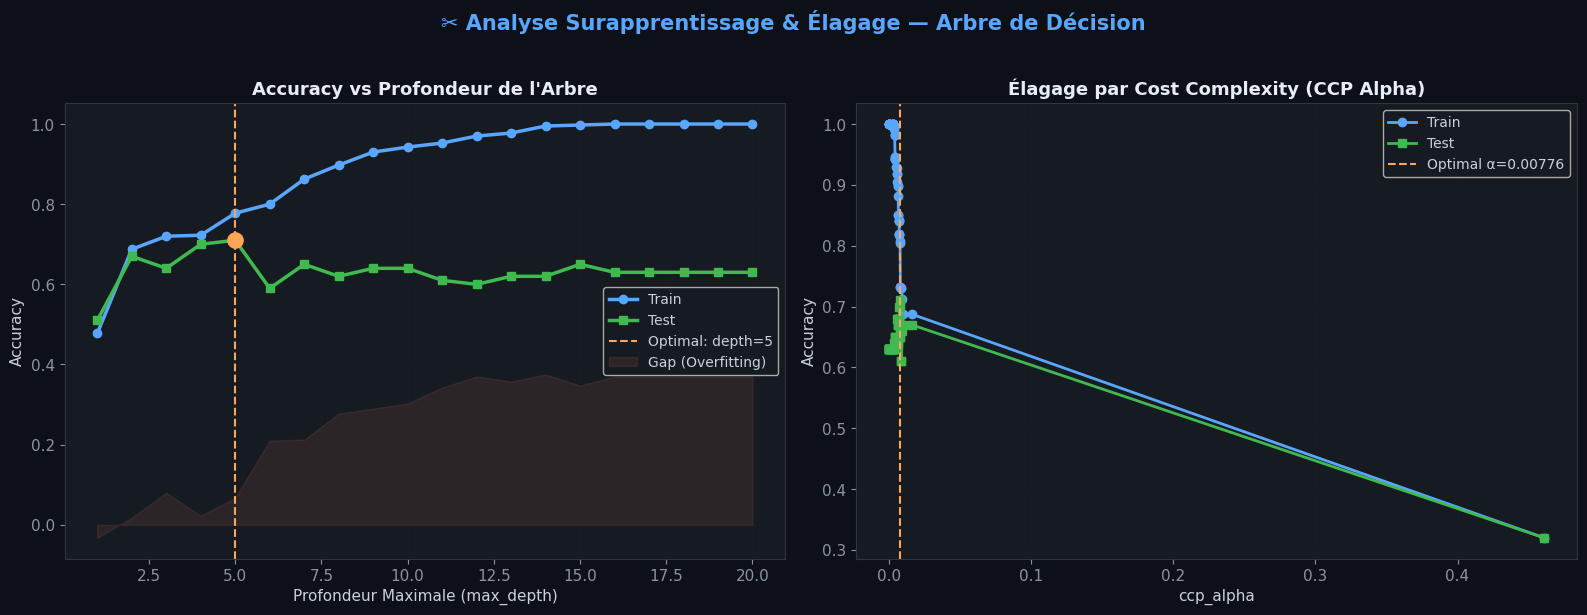

In [25]:
# Validation Curve — max_depth
depths = range(1, 21)
train_accs, test_accs = [], []
for d in depths:
    dt_tmp = DecisionTreeClassifier(
        max_depth=d, criterion=best_dt.criterion,
        class_weight='balanced',
        random_state=42
    )
    dt_tmp.fit(X_train, y_train)
    train_accs.append(dt_tmp.score(X_train, y_train))
    test_accs.append(dt_tmp.score(X_test, y_test))

# CCP Alpha — Cost Complexity Pruning
path = best_dt.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
ccp_accuracies_train, ccp_accuracies_test = [], []
for alpha in ccp_alphas:
    # Ensure ccp_alpha is non-negative
    alpha = max(0, alpha)
    dt_ccp = DecisionTreeClassifier(
        ccp_alpha=alpha, criterion=best_dt.criterion,
        class_weight='balanced', random_state=42
    )
    dt_ccp.fit(X_train, y_train)
    ccp_accuracies_train.append(dt_ccp.score(X_train, y_train))
    ccp_accuracies_test.append(dt_ccp.score(X_test, y_test))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0d1117')

# Overfitting vs max_depth
axes[0].plot(depths, train_accs, 'o-', color='#58a6ff', linewidth=2.5, label='Train')
axes[0].plot(depths, test_accs, 's-', color='#3fb950', linewidth=2.5, label='Test')
best_depth_idx = np.argmax(test_accs)
axes[0].axvline(x=depths[best_depth_idx], color='#ffa657', linestyle='--',
                linewidth=1.5, label=f'Optimal: depth={depths[best_depth_idx]}')
axes[0].scatter([depths[best_depth_idx]], [test_accs[best_depth_idx]], color='#ffa657', s=120, zorder=5)
axes[0].fill_between(depths,
    [t - v for t, v in zip(train_accs, test_accs)],
    0, alpha=0.1, color='#f78166', label='Gap (Overfitting)')
axes[0].set_title('Accuracy vs Profondeur de l\'Arbre',
                   fontweight='bold', color='#e6edf3', fontsize=13)
axes[0].set_xlabel('Profondeur Maximale (max_depth)')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=10)
axes[0].set_facecolor('#161b22')
axes[0].grid(alpha=0.2)

# CCP Alpha pruning
axes[1].plot(ccp_alphas, ccp_accuracies_train, 'o-', color='#58a6ff', linewidth=2, label='Train')
axes[1].plot(ccp_alphas, ccp_accuracies_test, 's-', color='#3fb950', linewidth=2, label='Test')
best_alpha_idx = np.argmax(ccp_accuracies_test)
axes[1].axvline(x=ccp_alphas[best_alpha_idx], color='#ffa657', linestyle='--',
                linewidth=1.5, label=f'Optimal α={ccp_alphas[best_alpha_idx]:.5f}')
axes[1].set_title('Élagage par Cost Complexity (CCP Alpha)',
                   fontweight='bold', color='#e6edf3', fontsize=13)
axes[1].set_xlabel('ccp_alpha')
axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=10)
axes[1].set_facecolor('#161b22')
axes[1].grid(alpha=0.2)

plt.suptitle('✂️ Analyse Surapprentissage & Élagage — Arbre de Décision',
             fontsize=15, fontweight='bold', color='#58a6ff', y=1.02)
plt.tight_layout()
plt.show()

## 🔍 7. Importance des Features & Règles de Décision

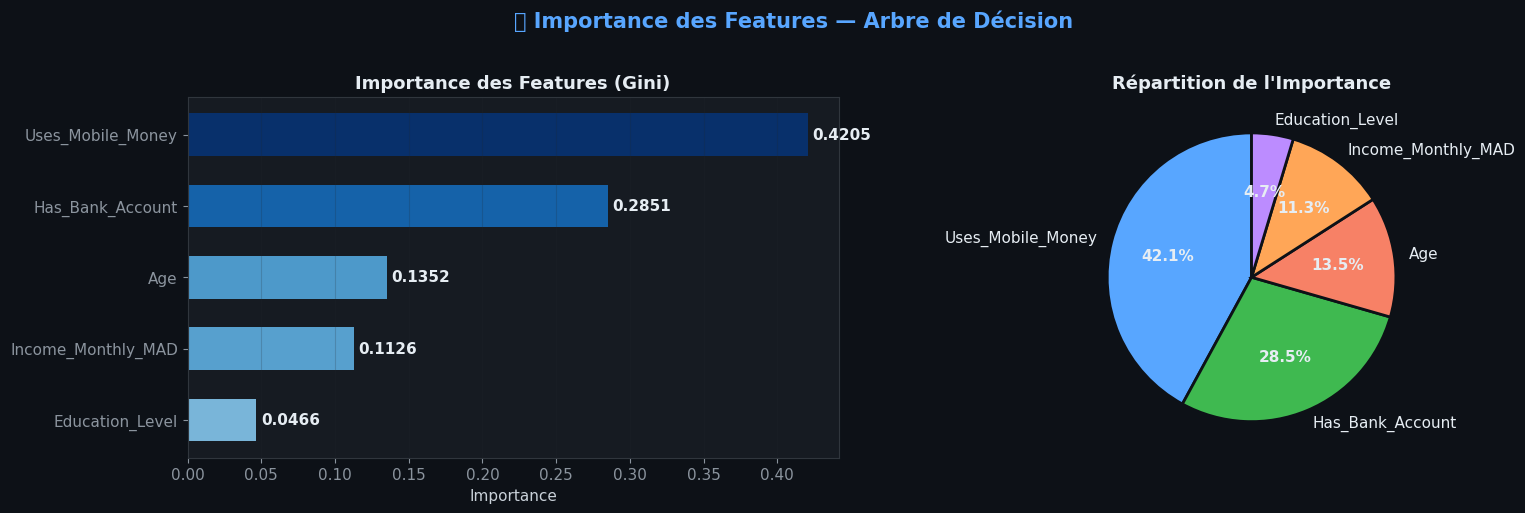


📊 Tableau des importances:


,Feature,Importance
0,Uses_Mobile_Money,0.420526
1,Has_Bank_Account,0.285073
2,Age,0.135156
3,Income_Monthly_MAD,0.112604
4,Education_Level,0.046641


In [26]:
# Feature Importance
feature_names = X.columns.tolist()
importances = best_dt.feature_importances_
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})\
         .sort_values('Importance', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0d1117')

# Bar horizontal
fi_sorted = fi_df.sort_values('Importance')
cmap = plt.cm.Blues
bar_colors = [cmap(0.4 + 0.6 * v / fi_sorted['Importance'].max()) for v in fi_sorted['Importance']]
bars = axes[0].barh(fi_sorted['Feature'], fi_sorted['Importance'],
                     color=bar_colors, edgecolor='none', height=0.6)
for bar, val in zip(bars, fi_sorted['Importance']):
    axes[0].text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=11, fontweight='bold', color='#e6edf3')
axes[0].set_title('Importance des Features (Gini)',
                   fontweight='bold', color='#e6edf3', fontsize=13)
axes[0].set_xlabel('Importance')
axes[0].set_facecolor('#161b22')
axes[0].grid(axis='x', alpha=0.2)

# Pie
wedge_colors = ['#58a6ff', '#3fb950', '#f78166', '#ffa657', '#bc8cff']
wedges, texts, autos = axes[1].pie(
    fi_df['Importance'], labels=fi_df['Feature'],
    colors=wedge_colors[:len(fi_df)], autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': '#0d1117', 'linewidth': 2},
    textprops={'color': '#e6edf3', 'fontsize': 11}
)
for at in autos:
    at.set_fontweight('bold')
axes[1].set_title('Répartition de l\'Importance',
                   fontweight='bold', color='#e6edf3', fontsize=13)

plt.suptitle('🔍 Importance des Features — Arbre de Décision',
             fontsize=15, fontweight='bold', color='#58a6ff', y=1.02)
plt.tight_layout()
plt.show()

print('\n📊 Tableau des importances:')
display(fi_df)

In [27]:
# Export des règles de décision textuelles
from sklearn.tree import export_text

rules = export_text(
    best_dt,
    feature_names=feature_names,
    max_depth=5,
    show_weights=True
)
print('📜 RÈGLES DE L\'ARBRE DE DÉCISION (top 5 niveaux):')
print('='*60)
print(rules[:3000] + '...\n[Affichage tronqué — voir arbre complet ci-dessus]')

📜 RÈGLES DE L'ARBRE DE DÉCISION (top 5 niveaux):
|--- Has_Bank_Account <= 0.50
|   |--- Uses_Mobile_Money <= 0.50
|   |   |--- weights: [133.33, 0.00, 0.00] class: 0
|   |--- Uses_Mobile_Money >  0.50
|   |   |--- Income_Monthly_MAD <= 3110.50
|   |   |   |--- Income_Monthly_MAD <= 2684.00
|   |   |   |   |--- weights: [0.00, 1.04, 1.55] class: 2
|   |   |   |--- Income_Monthly_MAD >  2684.00
|   |   |   |   |--- Income_Monthly_MAD <= 2833.00
|   |   |   |   |   |--- weights: [0.00, 2.08, 0.00] class: 1
|   |   |   |   |--- Income_Monthly_MAD >  2833.00
|   |   |   |   |   |--- weights: [0.00, 2.08, 0.00] class: 1
|   |   |--- Income_Monthly_MAD >  3110.50
|   |   |   |--- Income_Monthly_MAD <= 6566.00
|   |   |   |   |--- Age <= 44.00
|   |   |   |   |   |--- weights: [0.00, 0.00, 7.75] class: 2
|   |   |   |   |--- Age >  44.00
|   |   |   |   |   |--- Education_Level <= 1.50
|   |   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |   |   |--- Education_Level >  1.50
|  

## 🎯 8. Comparaison Critères & Résumé Final

📊 Comparaison des critères:


,CV Mean,CV Std,Test Acc,Depth,Leaves
gini,0.654,0.0150,0.60,10.0,82.0
entropy,0.638,0.0271,0.65,10.0,83.0
log_loss,0.638,0.0271,0.65,10.0,83.0


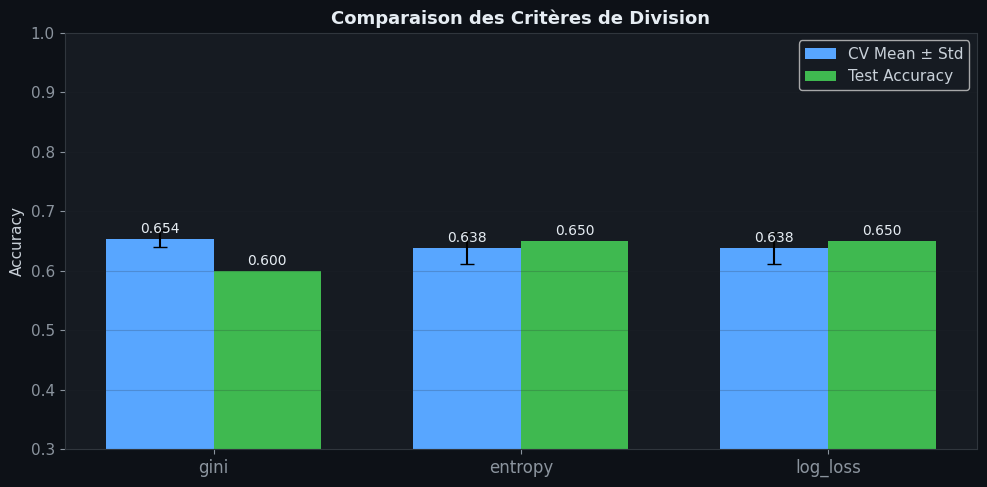

In [28]:
# Comparaison Gini vs Entropy vs Log Loss
criteria_results = {}
for criterion in ['gini', 'entropy', 'log_loss']:
    dt_tmp = DecisionTreeClassifier(
        criterion=criterion,
        max_depth=best_dt.get_depth(),
        min_samples_split=best_dt.min_samples_split,
        min_samples_leaf=best_dt.min_samples_leaf,
        class_weight='balanced', random_state=42
    )
    cv_sc = cross_val_score(dt_tmp, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    dt_tmp.fit(X_train, y_train)
    criteria_results[criterion] = {
        'CV Mean': cv_sc.mean(),
        'CV Std': cv_sc.std(),
        'Test Acc': dt_tmp.score(X_test, y_test),
        'Depth': dt_tmp.get_depth(),
        'Leaves': dt_tmp.get_n_leaves()
    }

criteria_df = pd.DataFrame(criteria_results).T
print('📊 Comparaison des critères:')
display(criteria_df.round(4))

# Graphique comparaison
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

x = np.arange(len(criteria_results))
width = 0.35
cv_means = [v['CV Mean'] for v in criteria_results.values()]
cv_stds  = [v['CV Std'] for v in criteria_results.values()]
test_accs_c = [v['Test Acc'] for v in criteria_results.values()]

bars1 = ax.bar(x - width/2, cv_means, width, yerr=cv_stds,
               color='#58a6ff', label='CV Mean ± Std', capsize=5, edgecolor='none')
bars2 = ax.bar(x + width/2, test_accs_c, width,
               color='#3fb950', label='Test Accuracy', edgecolor='none')

ax.set_xticks(x)
ax.set_xticklabels(list(criteria_results.keys()), fontsize=12)
ax.set_ylabel('Accuracy')
ax.set_ylim([0.3, 1.0])
ax.set_title('Comparaison des Critères de Division',
             fontweight='bold', color='#e6edf3', fontsize=13)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.2)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=10, color='#e6edf3')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=10, color='#e6edf3')

plt.tight_layout()
plt.show()

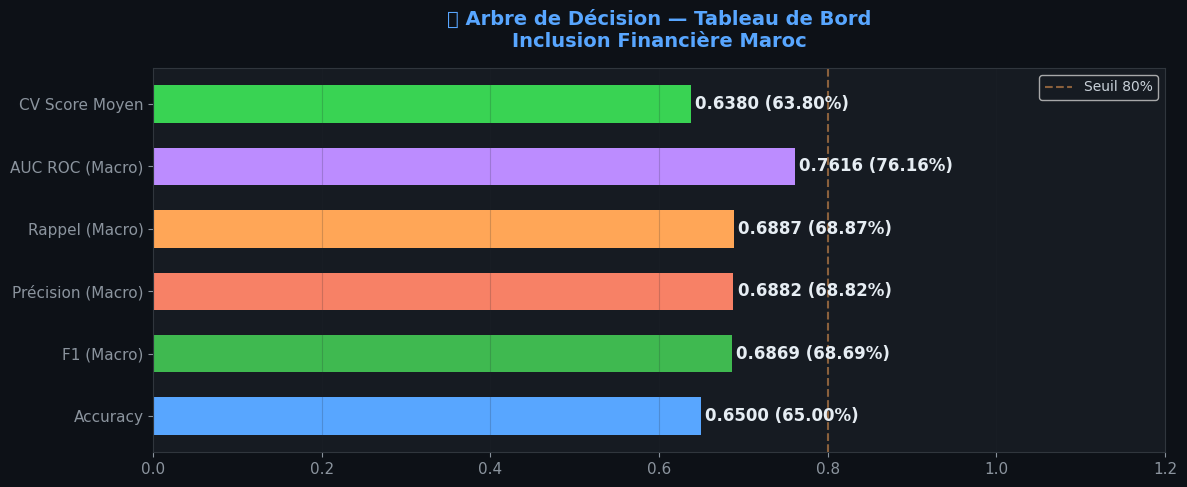


════════════════════════════════════════════════════════════
🏆 RÉSUMÉ FINAL — ARBRE DE DÉCISION
════════════════════════════════════════════════════════════
  Accuracy                 : 0.6500 (65.00%)
  F1 (Macro)               : 0.6869 (68.69%)
  Précision (Macro)        : 0.6882 (68.82%)
  Rappel (Macro)           : 0.6887 (68.87%)
  AUC ROC (Macro)          : 0.7616 (76.16%)
  CV Score Moyen           : 0.6380 (63.80%)
════════════════════════════════════════════════════════════
  Profondeur optimale      : 10
  Nombre de feuilles       : 83
  Critère utilisé          : entropy
  Meilleurs hyperparamètres: {'ccp_alpha': 0.0, 'criterion': 'entropy', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 2}
════════════════════════════════════════════════════════════


In [29]:
# Résumé final
from sklearn.metrics import f1_score, precision_score, recall_score

metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'F1 (Macro)': f1_score(y_test, y_pred, average='macro'),
    'Précision (Macro)': precision_score(y_test, y_pred, average='macro'),
    'Rappel (Macro)': recall_score(y_test, y_pred, average='macro'),
    'AUC ROC (Macro)': roc_auc_score(y_test_bin, y_proba, multi_class='ovr', average='macro'),
    'CV Score Moyen': cv_scores.mean()
}

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

colors = ['#58a6ff', '#3fb950', '#f78166', '#ffa657', '#bc8cff', '#39d353']
bars = ax.barh(list(metrics.keys()), list(metrics.values()),
               color=colors, edgecolor='none', height=0.6)
for bar, val in zip(bars, metrics.values()):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f} ({val*100:.2f}%)', va='center', fontsize=12,
            fontweight='bold', color='#e6edf3')
ax.set_xlim([0, 1.2])
ax.axvline(x=0.8, color='#ffa657', linestyle='--', linewidth=1.5, alpha=0.5, label='Seuil 80%')
ax.set_title('🌳 Arbre de Décision — Tableau de Bord\nInclusion Financière Maroc',
             fontsize=14, fontweight='bold', color='#58a6ff', pad=15)
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

print('\n' + '═'*60)
print('🏆 RÉSUMÉ FINAL — ARBRE DE DÉCISION')
print('═'*60)
for name, val in metrics.items():
    print(f'  {name:<25}: {val:.4f} ({val*100:.2f}%)')
print('═'*60)
print(f'  Profondeur optimale      : {best_dt.get_depth()}')
print(f'  Nombre de feuilles       : {best_dt.get_n_leaves()}')
print(f'  Critère utilisé          : {best_dt.criterion}')
print(f'  Meilleurs hyperparamètres: {grid_search.best_params_}')
print('═'*60)

# ⚡ Classification avec XGBoost & LightGBM
## Inclusion Financière au Maroc — Gradient Boosting Avancé

---
**Dataset :** `financial_inclusion_morocco.xlsx`  
**Cible :** `Financial_Inclusion` (Included / Partially Included / Excluded)  
**Algorithmes :** XGBoost + LightGBM (comparaison et ensemble)

---

## 📦 1. Installation & Imports

In [30]:
!pip install -q xgboost lightgbm openpyxl plotly kaleido shap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import shap
import warnings
warnings.filterwarnings('ignore')

# XGBoost & LightGBM
import xgboost as xgb
import lightgbm as lgb
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Sklearn
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    GridSearchCV, RandomizedSearchCV,
    StratifiedKFold, learning_curve
)
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score
)
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',
    'text.color': '#c9d1d9',
    'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'grid.color': '#21262d',
    'font.size': 11
})

XGB_COLOR  = '#f78166'
LGBM_COLOR = '#58a6ff'
ENS_COLOR  = '#3fb950'
PALETTE    = [XGB_COLOR, LGBM_COLOR, ENS_COLOR]

print('✅ Imports XGBoost, LightGBM, SHAP — OK!')

✅ Imports XGBoost, LightGBM, SHAP — OK!


## 📂 2. Chargement & Prétraitement

In [31]:
from google.colab import files
uploaded = files.upload()  # Uploader financial_inclusion_morocco.xlsx

df = pd.read_excel('financial_inclusion_morocco.xlsx')
print(f'📊 Shape: {df.shape}')
display(df.head(8))
print('\n🎯 Distribution cible:')
display(df['Financial_Inclusion'].value_counts())

Saving financial_inclusion_morocco.xlsx to financial_inclusion_morocco (2).xlsx
📊 Shape: (500, 6)


,Age,Income_Monthly_MAD,Education_Level,Has_Bank_Account,Uses_Mobile_Money,Financial_Inclusion
0,56,4843,Secondary,1,0,Partially Included
1,69,15000,Secondary,0,1,Partially Included
2,46,11162,Primary,0,0,Excluded
3,32,18464,University,0,0,Excluded
4,60,16625,University,1,1,Partially Included
5,25,9630,Primary,1,0,Partially Included
6,38,3179,University,0,1,Partially Included
7,56,5006,Primary,1,1,Partially Included



🎯 Distribution cible:


,count
Financial_Inclusion,
Partially Included,215
Included,160
Excluded,125


In [32]:
# Prétraitement
df_proc = df.copy()
le_edu    = LabelEncoder()
le_target = LabelEncoder()

df_proc['Education_Level']    = le_edu.fit_transform(df['Education_Level'])
df_proc['Financial_Inclusion'] = le_target.fit_transform(df['Financial_Inclusion'])

X = df_proc.drop('Financial_Inclusion', axis=1)
y = df_proc['Financial_Inclusion']

print('🏷️ Education_Level:', dict(zip(le_edu.classes_, le_edu.transform(le_edu.classes_))))
print('🏷️ Financial_Inclusion:', dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Poids de classe pour XGBoost
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight('balanced', y_train)

print(f'\n✅ Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print(f'✅ Features: {list(X.columns)}')

🏷️ Education_Level: {'Primary': np.int64(0), 'Secondary': np.int64(1), 'University': np.int64(2)}
🏷️ Financial_Inclusion: {'Excluded': np.int64(0), 'Included': np.int64(1), 'Partially Included': np.int64(2)}

✅ Train: 400 | Test: 100
✅ Features: ['Age', 'Income_Monthly_MAD', 'Education_Level', 'Has_Bank_Account', 'Uses_Mobile_Money']


## ⚡ 3. XGBoost — Entraînement & Optimisation

In [33]:
# XGBoost de base
xgb_base = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)
xgb_base.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)
print(f'⚡ XGBoost base — Accuracy: {xgb_base.score(X_test, y_test):.4f}')

⚡ XGBoost base — Accuracy: 0.6500


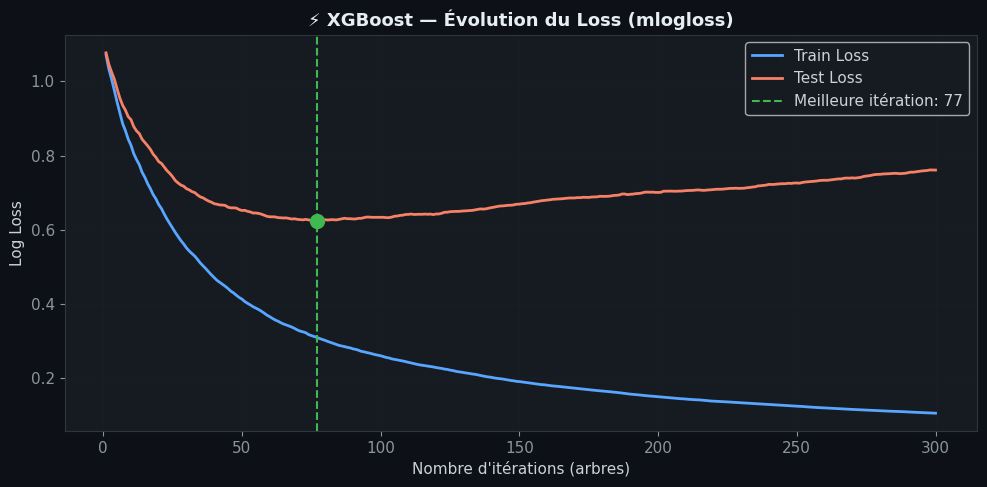

In [34]:
# Courbes d'apprentissage XGBoost (evals_result)
xgb_eval = XGBClassifier(
    objective='multi:softprob', num_class=3,
    n_estimators=300, learning_rate=0.05,
    max_depth=6, subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='mlogloss',
    random_state=42, n_jobs=-1
)
xgb_eval.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)
evals_result = xgb_eval.evals_result()

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

train_loss = evals_result['validation_0']['mlogloss']
test_loss  = evals_result['validation_1']['mlogloss']
iters = range(1, len(train_loss) + 1)

ax.plot(iters, train_loss, color='#58a6ff', linewidth=2, label='Train Loss')
ax.plot(iters, test_loss,  color='#f78166', linewidth=2, label='Test Loss')
best_iter = np.argmin(test_loss)
ax.axvline(x=best_iter + 1, color='#3fb950', linestyle='--',
           linewidth=1.5, label=f'Meilleure itération: {best_iter+1}')
ax.scatter([best_iter + 1], [test_loss[best_iter]], color='#3fb950', s=100, zorder=5)

ax.set_title('⚡ XGBoost — Évolution du Loss (mlogloss)',
             fontweight='bold', color='#e6edf3', fontsize=13)
ax.set_xlabel('Nombre d\'itérations (arbres)')
ax.set_ylabel('Log Loss')
ax.legend(fontsize=11)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [35]:
# GridSearchCV XGBoost
print('⚙️ GridSearchCV XGBoost en cours...\n')

xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.5],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [1, 1.5, 2]
}

xgb_model = XGBClassifier(
    objective='multi:softprob', num_class=3,
    use_label_encoder=False, eval_metric='mlogloss',
    random_state=42, n_jobs=-1
)

xgb_search = RandomizedSearchCV(
    xgb_model, xgb_param_grid, n_iter=60,
    cv=cv, scoring='accuracy', n_jobs=-1, verbose=1, random_state=42
)
xgb_search.fit(X_train, y_train, sample_weight=sample_weights)

print(f'\n🏆 XGBoost — Meilleurs paramètres:')
for k, v in xgb_search.best_params_.items():
    print(f'   {k}: {v}')
print(f'\n✅ Meilleur score CV: {xgb_search.best_score_:.4f}')

best_xgb = xgb_search.best_estimator_

⚙️ GridSearchCV XGBoost en cours...

Fitting 5 folds for each of 60 candidates, totalling 300 fits

🏆 XGBoost — Meilleurs paramètres:
   subsample: 0.7
   reg_lambda: 1
   reg_alpha: 0
   n_estimators: 300
   max_depth: 3
   learning_rate: 0.2
   gamma: 0.5
   colsample_bytree: 1.0

✅ Meilleur score CV: 0.6725


## 💡 4. LightGBM — Entraînement & Optimisation

In [36]:
# LightGBM de base
lgbm_base = LGBMClassifier(
    objective='multiclass',
    num_class=3,
    n_estimators=200,
    learning_rate=0.1,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm_base.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
)
print(f'💡 LightGBM base — Accuracy: {lgbm_base.score(X_test, y_test):.4f}')

💡 LightGBM base — Accuracy: 0.6500


In [37]:
# GridSearchCV LightGBM
print('⚙️ GridSearchCV LightGBM en cours...\n')

lgbm_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [-1, 3, 5, 7],
    'num_leaves': [15, 31, 63, 127],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [0, 0.1, 0.5],
    'min_child_samples': [10, 20, 30]
}

lgbm_model = LGBMClassifier(
    objective='multiclass', num_class=3,
    class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1
)

lgbm_search = RandomizedSearchCV(
    lgbm_model, lgbm_param_grid, n_iter=60,
    cv=cv, scoring='accuracy', n_jobs=-1, verbose=1, random_state=42
)
lgbm_search.fit(X_train, y_train)

print(f'\n🏆 LightGBM — Meilleurs paramètres:')
for k, v in lgbm_search.best_params_.items():
    print(f'   {k}: {v}')
print(f'\n✅ Meilleur score CV: {lgbm_search.best_score_:.4f}')

best_lgbm = lgbm_search.best_estimator_

⚙️ GridSearchCV LightGBM en cours...

Fitting 5 folds for each of 60 candidates, totalling 300 fits

🏆 LightGBM — Meilleurs paramètres:
   subsample: 1.0
   reg_lambda: 0
   reg_alpha: 0.1
   num_leaves: 31
   n_estimators: 300
   min_child_samples: 20
   max_depth: 5
   learning_rate: 0.05
   colsample_bytree: 0.8

✅ Meilleur score CV: 0.6750


## 📊 5. Évaluation Comparative XGBoost vs LightGBM

In [38]:
# Prédictions
y_pred_xgb  = best_xgb.predict(X_test)
y_proba_xgb = best_xgb.predict_proba(X_test)

y_pred_lgbm  = best_lgbm.predict(X_test)
y_proba_lgbm = best_lgbm.predict_proba(X_test)

acc_xgb  = accuracy_score(y_test, y_pred_xgb)
acc_lgbm = accuracy_score(y_test, y_pred_lgbm)

print('='*60)
print(f'📋 XGBoost — Rapport de Classification (Accuracy: {acc_xgb:.4f})')
print('='*60)
print(classification_report(y_test, y_pred_xgb, target_names=le_target.classes_))

print('='*60)
print(f'📋 LightGBM — Rapport de Classification (Accuracy: {acc_lgbm:.4f})')
print('='*60)
print(classification_report(y_test, y_pred_lgbm, target_names=le_target.classes_))

📋 XGBoost — Rapport de Classification (Accuracy: 0.6200)
                    precision    recall  f1-score   support

          Excluded       1.00      1.00      1.00        25
          Included       0.40      0.38      0.39        32
Partially Included       0.56      0.58      0.57        43

          accuracy                           0.62       100
         macro avg       0.65      0.65      0.65       100
      weighted avg       0.62      0.62      0.62       100

📋 LightGBM — Rapport de Classification (Accuracy: 0.6000)
                    precision    recall  f1-score   support

          Excluded       1.00      1.00      1.00        25
          Included       0.36      0.31      0.33        32
Partially Included       0.53      0.58      0.56        43

          accuracy                           0.60       100
         macro avg       0.63      0.63      0.63       100
      weighted avg       0.59      0.60      0.60       100



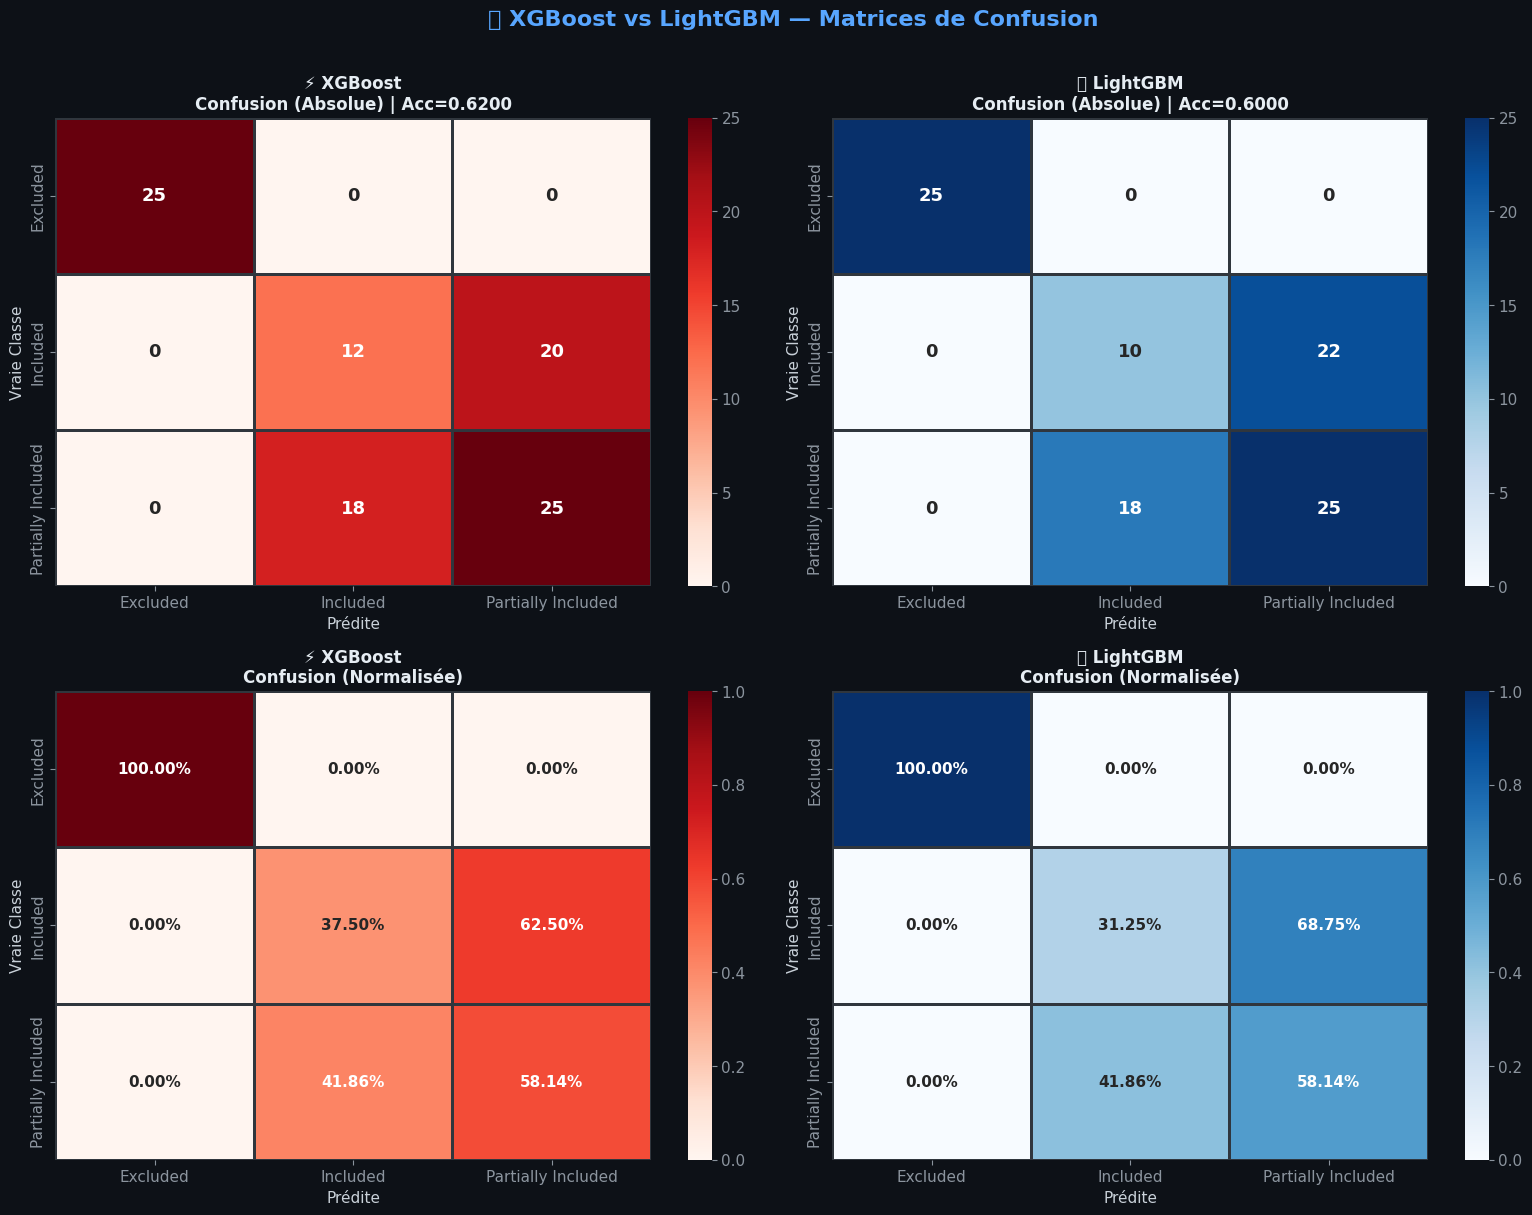

In [39]:
# Matrices de confusion côte à côte
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#0d1117')
classes = le_target.classes_

cms = [
    (confusion_matrix(y_test, y_pred_xgb), '⚡ XGBoost'),
    (confusion_matrix(y_test, y_pred_lgbm), '💡 LightGBM')
]
cmaps = ['Reds', 'Blues']

for col, ((cm, title), cmap) in enumerate(zip(cms, cmaps)):
    # Absolue
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[0, col], cmap=cmap,
                linewidths=1, linecolor='#30363d',
                xticklabels=classes, yticklabels=classes,
                annot_kws={'size': 13, 'weight': 'bold'})
    axes[0, col].set_title(f'{title}\nConfusion (Absolue) | Acc={accuracy_score(y_test, [y_pred_xgb, y_pred_lgbm][col]):.4f}',
                           fontweight='bold', color='#e6edf3', fontsize=12)
    axes[0, col].set_ylabel('Vraie Classe')
    axes[0, col].set_xlabel('Prédite')
    axes[0, col].set_facecolor('#161b22')

    # Normalisée
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, annot=True, fmt='.2%', ax=axes[1, col], cmap=cmap,
                linewidths=1, linecolor='#30363d',
                xticklabels=classes, yticklabels=classes,
                annot_kws={'size': 11, 'weight': 'bold'})
    axes[1, col].set_title(f'{title}\nConfusion (Normalisée)',
                           fontweight='bold', color='#e6edf3', fontsize=12)
    axes[1, col].set_ylabel('Vraie Classe')
    axes[1, col].set_xlabel('Prédite')
    axes[1, col].set_facecolor('#161b22')

plt.suptitle('🔥 XGBoost vs LightGBM — Matrices de Confusion',
             fontsize=16, fontweight='bold', color='#58a6ff', y=1.01)
plt.tight_layout()
plt.show()

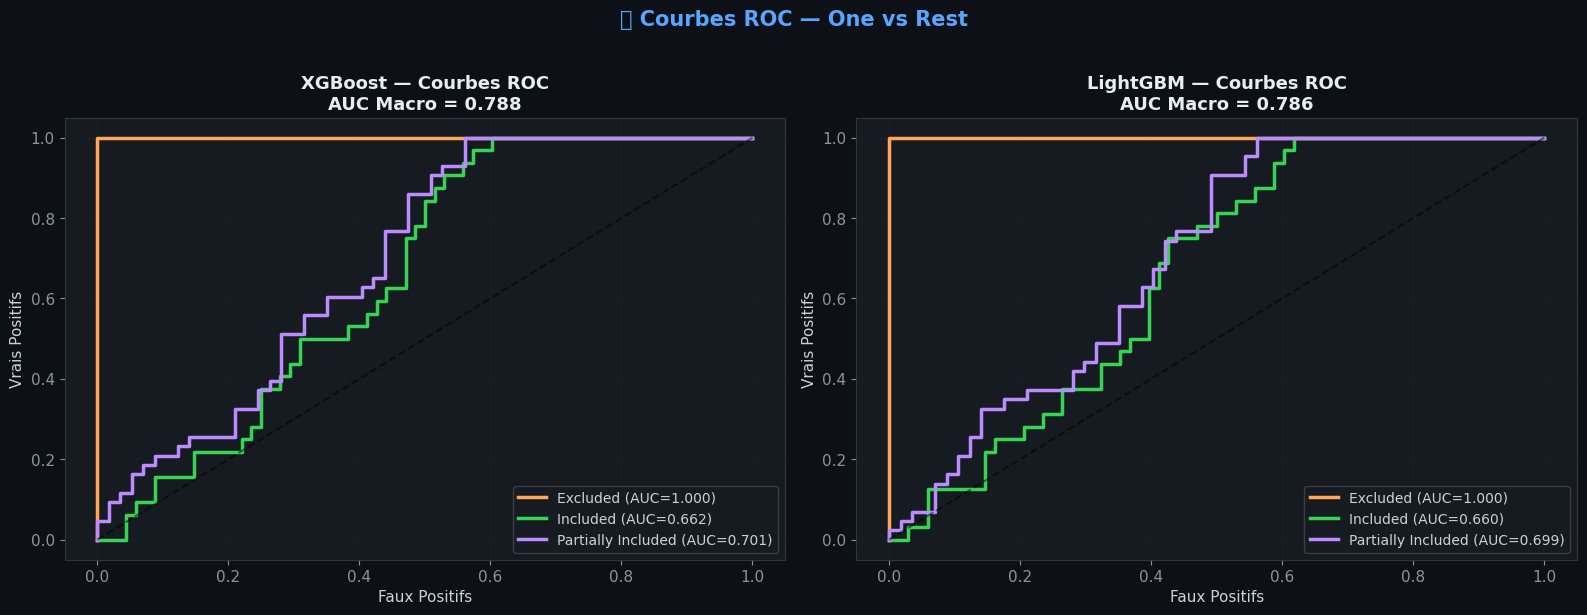

In [40]:
# Courbes ROC comparatives
n_classes = len(le_target.classes_)
y_test_bin = label_binarize(y_test, classes=range(n_classes))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0d1117')

for ax, (model_name, y_proba, color) in zip(axes, [
    ('XGBoost', y_proba_xgb, XGB_COLOR),
    ('LightGBM', y_proba_lgbm, LGBM_COLOR)
]):
    ax.set_facecolor('#161b22')
    auc_scores = []
    cls_colors = ['#ffa657', '#39d353', '#bc8cff']
    for i, (cls_name, cls_color) in enumerate(zip(le_target.classes_, cls_colors)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        auc_val = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
        auc_scores.append(auc_val)
        ax.plot(fpr, tpr, color=cls_color, linewidth=2.5,
                label=f'{cls_name} (AUC={auc_val:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.5)
    ax.set_xlabel('Faux Positifs')
    ax.set_ylabel('Vrais Positifs')
    ax.set_title(f'{model_name} — Courbes ROC\nAUC Macro = {np.mean(auc_scores):.3f}',
                 fontweight='bold', color='#e6edf3', fontsize=13)
    ax.legend(fontsize=10, framealpha=0.2)
    ax.grid(alpha=0.2)

plt.suptitle('🏆 Courbes ROC — One vs Rest',
             fontsize=15, fontweight='bold', color='#58a6ff', y=1.02)
plt.tight_layout()
plt.show()

## 🔍 6. Feature Importance — MDI & SHAP

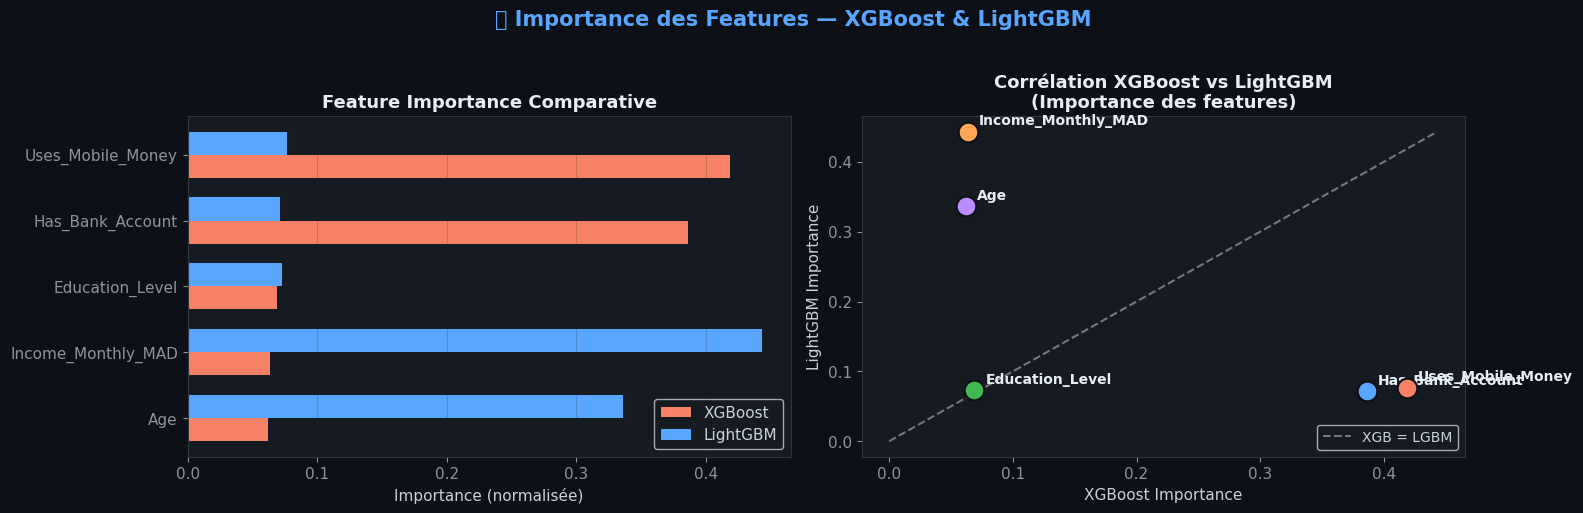

In [41]:
# Importance comparative XGBoost vs LightGBM
feature_names = list(X.columns)

xgb_imp  = best_xgb.feature_importances_
lgbm_imp = best_lgbm.feature_importances_ / best_lgbm.feature_importances_.sum()

fi_df = pd.DataFrame({
    'Feature': feature_names,
    'XGBoost': xgb_imp,
    'LightGBM': lgbm_imp
}).sort_values('XGBoost', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0d1117')

x = np.arange(len(feature_names))
width = 0.35

# Grouped bar chart
fi_sorted = fi_df.sort_values('XGBoost')
axes[0].barh(np.arange(len(fi_sorted)) - width/2, fi_sorted['XGBoost'],
             height=width, color=XGB_COLOR, label='XGBoost', edgecolor='none')
axes[0].barh(np.arange(len(fi_sorted)) + width/2, fi_sorted['LightGBM'],
             height=width, color=LGBM_COLOR, label='LightGBM', edgecolor='none')
axes[0].set_yticks(np.arange(len(fi_sorted)))
axes[0].set_yticklabels(fi_sorted['Feature'])
axes[0].set_title('Feature Importance Comparative',
                   fontweight='bold', color='#e6edf3', fontsize=13)
axes[0].set_xlabel('Importance (normalisée)')
axes[0].legend(fontsize=11)
axes[0].set_facecolor('#161b22')
axes[0].grid(axis='x', alpha=0.2)

# Scatter plot XGBoost vs LightGBM importance
scatter_colors = ['#f78166', '#58a6ff', '#3fb950', '#ffa657', '#bc8cff']
for i, (feat, xval, lval) in enumerate(zip(fi_df['Feature'], fi_df['XGBoost'], fi_df['LightGBM'])):
    axes[1].scatter(xval, lval, color=scatter_colors[i % len(scatter_colors)],
                    s=200, zorder=5, edgecolors='#0d1117', linewidth=1.5)
    axes[1].annotate(feat, (xval, lval), textcoords='offset points',
                     xytext=(8, 5), fontsize=10, color='#e6edf3', fontweight='bold')

# Ligne de référence
max_val = max(fi_df['XGBoost'].max(), fi_df['LightGBM'].max())
axes[1].plot([0, max_val], [0, max_val], 'w--', linewidth=1.5, alpha=0.4, label='XGB = LGBM')
axes[1].set_title('Corrélation XGBoost vs LightGBM\n(Importance des features)',
                   fontweight='bold', color='#e6edf3', fontsize=13)
axes[1].set_xlabel('XGBoost Importance')
axes[1].set_ylabel('LightGBM Importance')
axes[1].legend(fontsize=10)
axes[1].set_facecolor('#161b22')
axes[1].grid(alpha=0.2)

plt.suptitle('🔍 Importance des Features — XGBoost & LightGBM',
             fontsize=15, fontweight='bold', color='#58a6ff', y=1.02)
plt.tight_layout()
plt.show()

🔬 Calcul des valeurs SHAP (XGBoost)...


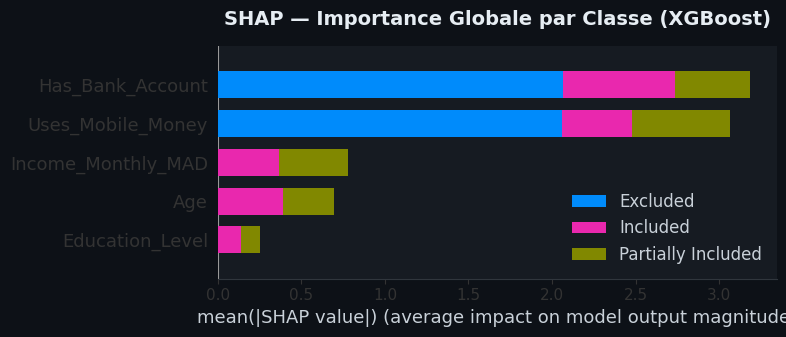

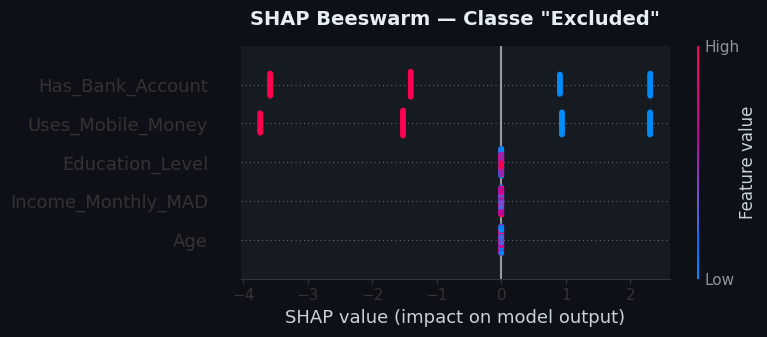

In [43]:
# SHAP Values — Interprétabilité avancée
print('🔬 Calcul des valeurs SHAP (XGBoost)...')

explainer_xgb = shap.TreeExplainer(best_xgb)
shap_values_xgb = explainer_xgb.shap_values(X_test)

# SHAP Summary Plot
plt.figure(figsize=(12, 6))
plt.gcf().set_facecolor('#0d1117')
shap.summary_plot(
    shap_values_xgb,
    X_test,
    feature_names=feature_names,
    class_names=le_target.classes_,
    plot_type='bar',
    show=False
)
plt.title('SHAP — Importance Globale par Classe (XGBoost)',
          fontweight='bold', color='#e6edf3', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# SHAP Beeswarm pour la première classe
plt.figure(figsize=(12, 5))
plt.gcf().set_facecolor('#0d1117')
shap.summary_plot(
    shap_values_xgb[0] if isinstance(shap_values_xgb, list) else shap_values_xgb[:, :, 0],
    X_test,
    feature_names=feature_names,
    show=False
)
plt.title(f'SHAP Beeswarm — Classe "{le_target.classes_[0]}"',
          fontweight='bold', color='#e6edf3', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

## 🤝 7. Ensemble — Stacking XGBoost + LightGBM

In [44]:
# Soft Voting Ensemble
voting_clf = VotingClassifier(
    estimators=[
        ('xgb', best_xgb),
        ('lgbm', best_lgbm)
    ],
    voting='soft',
    weights=[1, 1]
)
voting_clf.fit(X_train, y_train)
y_pred_voting = voting_clf.predict(X_test)
acc_voting = accuracy_score(y_test, y_pred_voting)
print(f'🤝 Soft Voting Ensemble — Accuracy: {acc_voting:.4f}')

# Stacking
stacking_clf = StackingClassifier(
    estimators=[
        ('xgb', best_xgb),
        ('lgbm', best_lgbm)
    ],
    final_estimator=LogisticRegression(max_iter=1000, C=1.0),
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1
)
stacking_clf.fit(X_train, y_train)
y_pred_stack = stacking_clf.predict(X_test)
acc_stack = accuracy_score(y_test, y_pred_stack)
print(f'📚 Stacking Ensemble — Accuracy: {acc_stack:.4f}')

🤝 Soft Voting Ensemble — Accuracy: 0.6000
📚 Stacking Ensemble — Accuracy: 0.6300


## 🏆 8. Comparaison Finale — Tous Modèles

In [45]:
# Tableau comparatif complet
models_dict = {
    'XGBoost': (best_xgb, y_pred_xgb, y_proba_xgb),
    'LightGBM': (best_lgbm, y_pred_lgbm, y_proba_lgbm),
    'Soft Voting': (voting_clf, y_pred_voting, voting_clf.predict_proba(X_test)),
    'Stacking': (stacking_clf, y_pred_stack, stacking_clf.predict_proba(X_test))
}

results = []
for name, (model, y_pred, y_proba) in models_dict.items():
    cv_sc = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    auc = roc_auc_score(y_test_bin, y_proba, multi_class='ovr', average='macro')
    results.append({
        'Modèle': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1 Macro': f1_score(y_test, y_pred, average='macro'),
        'Précision': precision_score(y_test, y_pred, average='macro'),
        'Rappel': recall_score(y_test, y_pred, average='macro'),
        'AUC ROC': auc,
        'CV Mean': cv_sc.mean(),
        'CV Std': cv_sc.std()
    })

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print('📊 Tableau Comparatif Final:')
display(results_df.round(4))

📊 Tableau Comparatif Final:


,Modèle,Accuracy,F1 Macro,Précision,Rappel,AUC ROC,CV Mean,CV Std
3,Stacking,0.63,0.6262,0.6349,0.6439,0.7961,0.656,0.0383
0,XGBoost,0.62,0.6518,0.6519,0.6521,0.7876,0.656,0.0408
1,LightGBM,0.60,0.6296,0.6297,0.6313,0.7864,0.662,0.0343
2,Soft Voting,0.60,0.6334,0.6333,0.6340,0.7922,0.656,0.0320


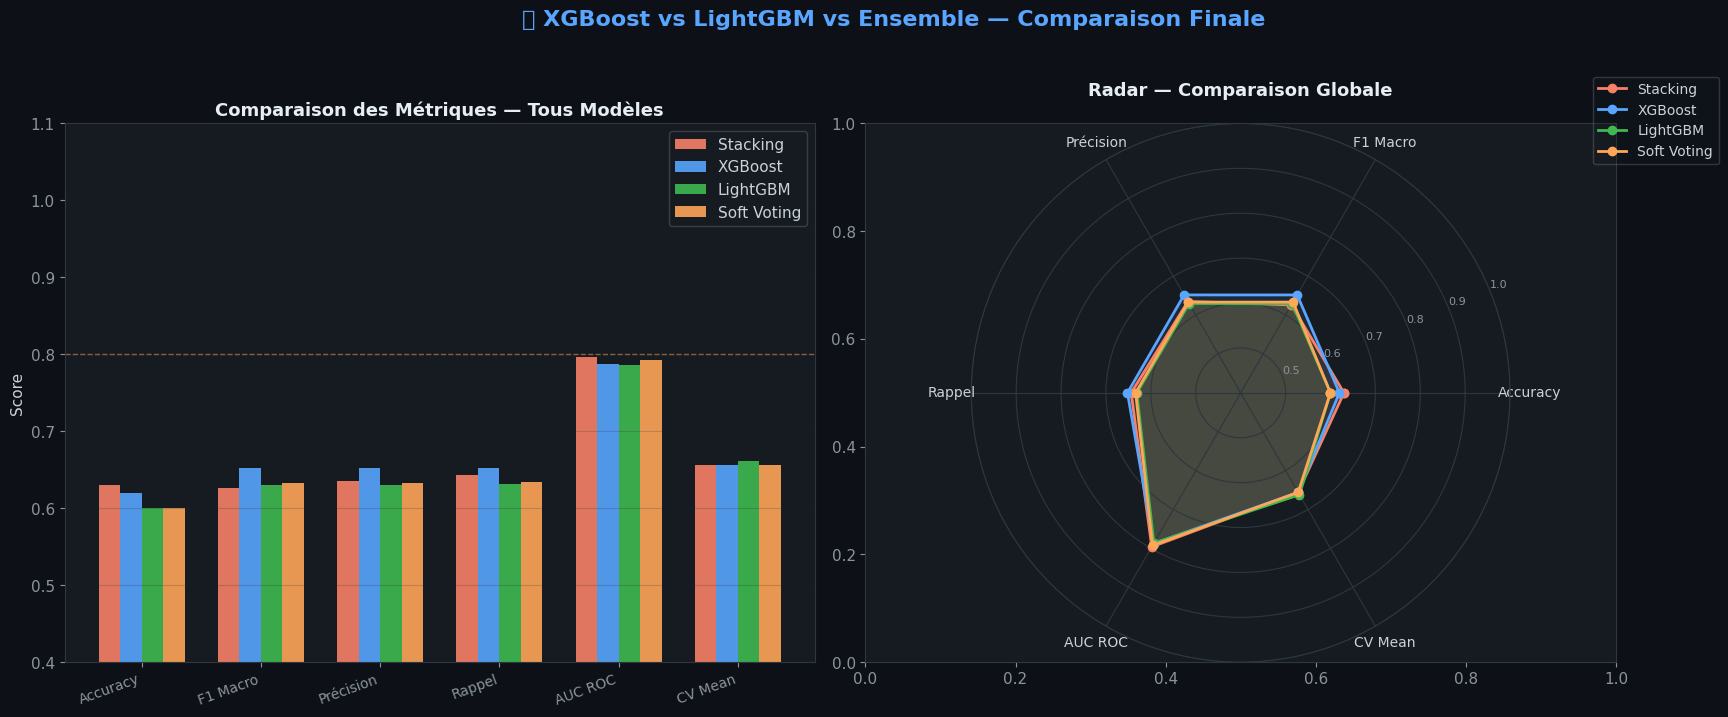

In [49]:
# Visualisation comparative finale
metrics_cols = ['Accuracy', 'F1 Macro', 'Précision', 'Rappel', 'AUC ROC', 'CV Mean']
model_colors = [XGB_COLOR, LGBM_COLOR, ENS_COLOR, '#ffa657']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#0d1117')

# Convert DataFrame rows to a list of dictionaries for easier iteration
results_list = results_df.to_dict('records')

# Grouped bar chart toutes métriques
x = np.arange(len(metrics_cols))
width = 0.18
for i, (row_dict, color) in enumerate(zip(results_list, model_colors)):
    vals = [row_dict[m] for m in metrics_cols] # Access values using dictionary keys
    axes[0].bar(x + i * width, vals, width, label=row_dict['Modèle'],
                color=color, edgecolor='none', alpha=0.9)

axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(metrics_cols, rotation=20, ha='right', fontsize=10)
axes[0].set_ylabel('Score')
axes[0].set_ylim([0.4, 1.1])
axes[0].set_title('Comparaison des Métriques — Tous Modèles',
                   fontweight='bold', color='#e6edf3', fontsize=13)
axes[0].legend(fontsize=11, framealpha=0.2)
axes[0].set_facecolor('#161b22')
axes[0].grid(axis='y', alpha=0.2)
axes[0].axhline(y=0.8, color='#ffa657', linestyle='--', linewidth=1, alpha=0.5)

# Radar chart
from matplotlib.patches import FancyArrowPatch
import matplotlib.patheffects as pe

categories = metrics_cols
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

ax_radar = plt.subplot(1, 2, 2, polar=True)
ax_radar.set_facecolor('#161b22')
ax_radar.spines['polar'].set_color('#30363d')

for row_dict, color in zip(results_list, model_colors):
    vals = [row_dict[m] for m in metrics_cols]
    vals += vals[:1]
    ax_radar.plot(angles, vals, 'o-', linewidth=2, color=color, label=row_dict['Modèle'])
    ax_radar.fill(angles, vals, alpha=0.1, color=color)

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(categories, fontsize=10, color='#c9d1d9')
ax_radar.set_ylim(0.4, 1.0)
ax_radar.set_yticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
ax_radar.set_yticklabels(['0.5', '0.6', '0.7', '0.8', '0.9', '1.0'], fontsize=8, color='#8b949e')
ax_radar.grid(color='#30363d', linewidth=0.8)
ax_radar.set_title('Radar — Comparaison Globale',
                   fontweight='bold', color='#e6edf3', fontsize=13, pad=20)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=10, framealpha=0.2)

plt.suptitle('🏆 XGBoost vs LightGBM vs Ensemble — Comparaison Finale',
             fontsize=16, fontweight='bold', color='#58a6ff', y=1.02)
plt.tight_layout()
plt.show()

In [50]:
# Résumé final
best_model_row = results_df.iloc[0]

print('\n' + '═'*70)
print('🏆 RÉSUMÉ FINAL — XGBoost + LightGBM + Ensembles')
print('═'*70)
print(f'\n🥇 MEILLEUR MODÈLE: {best_model_row["Modèle"]}')
print(f'   Accuracy  : {best_model_row["Accuracy"]:.4f} ({best_model_row["Accuracy"]*100:.2f}%)')
print(f'   F1 Macro  : {best_model_row["F1 Macro"]:.4f}')
print(f'   AUC ROC   : {best_model_row["AUC ROC"]:.4f}')
print(f'   CV Mean   : {best_model_row["CV Mean"]:.4f} ± {best_model_row["CV Std"]:.4f}')

print('\n📊 Classement complet:')
for i, row in results_df.iterrows():
    print(f'   {row["Modèle"]:<20} Acc={row["Accuracy"]:.4f} | F1={row["F1 Macro"]:.4f} | AUC={row["AUC ROC"]:.4f}')

print('\n⚡ XGBoost meilleurs hyperparamètres:')
for k, v in xgb_search.best_params_.items():
    print(f'   {k}: {v}')

print('\n💡 LightGBM meilleurs hyperparamètres:')
for k, v in lgbm_search.best_params_.items():
    print(f'   {k}: {v}')
print('═'*70)


══════════════════════════════════════════════════════════════════════
🏆 RÉSUMÉ FINAL — XGBoost + LightGBM + Ensembles
══════════════════════════════════════════════════════════════════════

🥇 MEILLEUR MODÈLE: Stacking
   Accuracy  : 0.6300 (63.00%)
   F1 Macro  : 0.6262
   AUC ROC   : 0.7961
   CV Mean   : 0.6560 ± 0.0383

📊 Classement complet:
   Stacking             Acc=0.6300 | F1=0.6262 | AUC=0.7961
   XGBoost              Acc=0.6200 | F1=0.6518 | AUC=0.7876
   LightGBM             Acc=0.6000 | F1=0.6296 | AUC=0.7864
   Soft Voting          Acc=0.6000 | F1=0.6334 | AUC=0.7922

⚡ XGBoost meilleurs hyperparamètres:
   subsample: 0.7
   reg_lambda: 1
   reg_alpha: 0
   n_estimators: 300
   max_depth: 3
   learning_rate: 0.2
   gamma: 0.5
   colsample_bytree: 1.0

💡 LightGBM meilleurs hyperparamètres:
   subsample: 1.0
   reg_lambda: 0
   reg_alpha: 0.1
   num_leaves: 31
   n_estimators: 300
   min_child_samples: 20
   max_depth: 5
   learning_rate: 0.05
   colsample_bytree: 0.8
════